# **Proyecto de Analisis de Mantenimiento Industrial**


## Descripcion del Proyecto
Se analizara una base de datos recolectados por el sector de mantenimiento dentro de un sector productivo, con el **objetivo** de desarrollar de un sistema predictivo capaz de reducir el Downtime en un 15% y mejorar el OEE mediante el monitoreo de sensores de temperatura y torque.

**Base de datos:**
“AI4I 2020 Predictive Maintenance Dataset” del repositorio UCI Machine Learning. Base de datos que contiene datos sinteticos basados en realidad industrial.
Simula ser un registro historico que contiene variables de produccion entre las cuales estan temperatura del aire, temperatura del proceso, calidad del producto, y la variable objetivo “Machine Failure” (Fallo mecanico) y sus distintos tipos de fallos en el proceso.

Link: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset


## PLANIFICAR
Familiarizarnos con los datos y el contexto del problema.


### **Preguntas que responder en esta etapa:**
- ¿Quienes conforman las partes interesadas en este proyecto?
- ¿Qué estamos intentando resolver o realizar en este proyecto?
- ¿Cuales son nuestras observaciones iniciales de los datos?
- ¿Qué recursos o fuentes hemos utilizado en esta etapa?
- ¿Tenemos alguna consideración ética en esta etapa?


#### 
- Las partes interesadas de este proyecto son la directiva del area de mantenimiento que utilizara las conclusiones para tomar decisiones a corto, mediano y largo plazo.
- Buscaremos desarrollar un sistema predictivo que reduzca los tiempos de parada y de esta forma mejorar los indicadores de rendimiento como el OEE.
- Nuestra observaciones iniciales indican que la calidad de los productos producidos esta relaionada con el desgaste de las maquinas y por lo tanto con la frecuencia de las fallas.
- Nos limitamos a utilizar como fuente principal la base de datos y sus especificaciones, SQL Server Management Studio, un entorno de trabajo de jupyter notebooky  un visualizador de datos como power BI.


### Entendiendo el dataset
El dataset tiene un tamaño de 1000 filas y 14 columnas de las variables citadas a continuacion.
| Variable| Significado Ingenieril| Por qué importa|
|-|-|-|
|Air temperature [K]|	Temperatura ambiente|	Afecta la capacidad de disipación de calor de la máquina.|
|Process temperature [K]|	Temperatura del proceso|	Si es muy alta respecto a la ambiente, indica ineficiencia térmica.|
|Rotational speed [rpm]|	Velocidad del husillo|	Alta velocidad puede generar vibraciones si no está balanceada.|
|Torque [Nm]|	Par motor| Fuerza de giro. Si el torque sube y la velocidad baja, hay obstrucción.|
|Tool wear [min]|	Desgaste de herramienta|	Tiempo acumulado de uso. Variable clave para mantenimiento preventivo.|
|Machine failure|	TARGET (Objetivo)|	1 = Falla, 0 = Funciona. Esto es lo que vamos a predecir.|

### Informacion y origen de las variables
Acontinuacion daremos informacion que nos proporciona el recolector de los datos sobre el dataset.

| Variable | Name | Role | Type | Description | Units | Missing Values |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| UID | ID | Integer | | unique identifier ranging from 1 to 10000 | | no |
| Product ID | ID | Categorical | | letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial numbe | | no |
| Type | Feature | Categorical | | | | no |
| Air temperature | Feature | Continuous | | generated using a random walk process later normalized to a standard deviation of 2 K around 300 K | K | no |
| Process temperature | Feature | Continuous | | generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K. | K | no |
| Rotational speed | Feature | Integer | | calculated from a power of 2860 W, overlaid with a normally distributed noise | rpm | no |
| Torque | Feature | Continuous | | torque values are normally distributed around 40 Nm with a Ïƒ = 10 Nm and no negative values. | Nm | no |
| Tool wear | Feature | Integer | | The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process. and a'machine failure' label that indicates, whether the machine has failed in this particular datapoint for any of the following failure modes are true. | min | no |
| Machine failure | Target | Integer | | The machine failure consists of five independent failure modes | | no |
| TWF | Target | Integer | | the tool will be replaced of fail at a randomly selected tool wear time between 200 – 240 mins (120 times in our dataset). At this point in time, the tool is replaced 69 times, and fails 51 times (randomly assigned). | | no |
| HDF | Target | Integer | | heat dissipation causes a process failure, if the difference between air- and process temperature is below 8.6 K and the tool’s rotational speed is below 1380 rpm. This is the case for 115 data points. | | no |
| PWF | Target | Integer | | the product of torque and rotational speed (in rad/s) equals the power required for the process. If this power is below 3500 W or above 9000 W, the process fails, which is the case 95 times in our dataset. | | no |
| OSF | Target | Integer | | if the product of tool wear and torque exceeds 11,000 minNm for the L product variant (12,000 M, 13,000 H), the process fails due to overstrain. This is true for 98 datapoints. | | no |
| RNF | Target | Integer | | each process has a chance of 0,1 % to fail regardless of its process parameters. This is the case for only 5 datapoints, less than could be expected for 10,000 datapoints in our dataset. | | no |

### Importar Paquetes de Python


In [121]:
# Import packages
### YOUR CODE HERE ### 

#for data manipulation
import numpy as np
import pandas as pd

#for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

#for data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier #Para nuestro caso que tenemos multiples salidas


#for metrics and helpful fuctions
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report,multilabel_confusion_matrix, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

#for saving models
import pickle

In [122]:
# Para poder importar desde la carpeta src
import sys
import os

# 1. Obtener la ruta absoluta del directorio actual del notebook
current_dir = os.getcwd()

# 2. Obtener la ruta de la raíz del proyecto (un nivel arriba)
project_root = os.path.dirname(current_dir)

# 3. Agregar la raíz al "Path" de Python para que pueda encontrar 'src'
sys.path.append(project_root)

# Verificación (Opcional)
print(f"Directorio raíz agregado: {project_root}")

Directorio raíz agregado: c:\Users\usuario\OneDrive\Documentos\PORTFOLIO\Poyecto_Raiz


In [123]:
import sys
import os

# 1. Tu configuración de rutas (que ya funcionó)
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

# 2. EL BLOQUE MÁGICO (Autoreload)
%load_ext autoreload
%autoreload 2

# 3. Ahora sí, importa
from src.data.make_dataset import obtener_datos_sql

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Crear Conexion con el servidor

Utilizando el paquete de `pyodbc` vamos a conectar nuestro jupyter notebook al servidor para obtener poder trabajar con nuestra base de datos `df`.

In [124]:
#importar la funcion del script make_dataset.py
from src.data.make_dataset import obtener_datos_sql

# Tú decides CUÁNDO ejecutarlo
print("Estoy listo para cargar datos...")

# La variable 'df' nace aquí,
df = obtener_datos_sql() 

df.head()

Estoy listo para cargar datos...


c:\Users\usuario\OneDrive\Documentos\PORTFOLIO\Poyecto_Raiz\src\data\make_dataset.py:29: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  # 4. Cerrar conexión (¡Buena práctica!)


✅ Datos cargados correctamente con SQLAlchemy.


,ï»¿UDI,Product ID,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.0,308.0,1551.0,42.0,0.0,0,0,0,0,0,0
1,2,L47181,L,298.0,308.0,1408.0,46.0,3.0,0,0,0,0,0,0
2,3,L47182,L,298.0,308.0,1498.0,49.0,5.0,0,0,0,0,0,0
3,4,L47183,L,298.0,308.0,1433.0,39.0,7.0,0,0,0,0,0,0
4,5,L47184,L,298.0,308.0,1408.0,40.0,9.0,0,0,0,0,0,0


### Renombrar Columnas para facilitar el manejo

In [125]:
#Renombrar columnas para facilitar su manejo
df.rename(columns={
    'ï»¿UDI': 'udi',
    'Product ID': 'product_id',
    'Type': 'type',
    'Air temperature  K ': 'air_temp_k',
    'Process temperature  K ': 'process_temp_k',
    'Rotational speed  rpm ': 'rotational_speed_rpm',
    'Torque  Nm ': 'torque_nm',
    'Tool wear  min ': 'tool_wear_min',
    'Machine failure': 'machine_failure',
    'TWF': 'tool_wear_failure',
    'HDF': 'heat_dissipation_failure',
    'PWF': 'power_failure',
    'OSF': 'overstrain_failure',
    'RNF': 'random_failure'
}, inplace=True)
print(df.columns.tolist())

['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure', 'random_failure']


### Detalles y metricas de las variables

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   udi                       10000 non-null  object 
 1   product_id                10000 non-null  object 
 2   type                      10000 non-null  object 
 3   air_temp_k                10000 non-null  float64
 4   process_temp_k            10000 non-null  float64
 5   rotational_speed_rpm      10000 non-null  float64
 6   torque_nm                 10000 non-null  float64
 7   tool_wear_min             10000 non-null  float64
 8   machine_failure           10000 non-null  int64  
 9   tool_wear_failure         10000 non-null  int64  
 10  heat_dissipation_failure  10000 non-null  int64  
 11  power_failure             10000 non-null  int64  
 12  overstrain_failure        10000 non-null  int64  
 13  random_failure            10000 non-null  int64  
dtypes: floa

In [127]:
df.head()

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
0,1,M14860,M,298.0,308.0,1551.0,42.0,0.0,0,0,0,0,0,0
1,2,L47181,L,298.0,308.0,1408.0,46.0,3.0,0,0,0,0,0,0
2,3,L47182,L,298.0,308.0,1498.0,49.0,5.0,0,0,0,0,0,0
3,4,L47183,L,298.0,308.0,1433.0,39.0,7.0,0,0,0,0,0,0
4,5,L47184,L,298.0,308.0,1408.0,40.0,9.0,0,0,0,0,0,0


In [128]:
#Detalles de los datos
df.describe()

,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,299.552200,309.552000,1538.776100,39.533400,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.014071,1.511597,179.284096,9.975662,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.000000,305.000000,1168.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.000000,308.000000,1423.000000,33.000000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.000000,310.000000,1503.000000,40.000000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.000000,311.000000,1612.000000,46.000000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.000000,313.000000,2886.000000,76.000000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


#### Analisis

**Temperatura del Aire y Temperatura del proceso**: Se puede ver que la temperatura del aire tiene una media de 299.6 (k) y la del proceso es 309.6(k), una desviacion estandar de la temperatura del aire ligeramente mayor a la del proceso, 2,01 y 1,51 respectivamente. 

IMPORTANCIA: Entre los posibles tipos de fallas que pueden ocurrir tenemos HDF(Falla por disipacion de calor), la disipacion de calor o transferencia de calor la podemos calcular como Q(calor) = K(coeficiente de transferencia de calor por conveccion) * A (Area de la superficie en contacto) * Delta Temperatura(T°proceso - T°aire), podemos considerar K y A constantes, por lo tanto debemos prestar atencion al Delta de Temperatura para lo cual convendria crear una columna de esta variable.


**Velocidad Rotacional de la fresadora** (máquina supuesta): se tiene un rango de 1721 rpm, una desviacion estandar de 179 rpm y una media de 1539 rpm.

**Torque de la máquina(Nm)**: un rango de 73, una desviacion de 10 y una media de 39.5 Nm. 

IMPORTANCIA: La potencia de la máquina se cacula como Torque x Velocidad angular(Rpm), por lo tanto si la potencia es constante habra una relacion inversa entre estas variables, si el aumento o disminucion de una no se compensa con la otra variable habra una variacion en la cantidad de potencia de la fresadora, pudiendo porvocar la falla del tipo PWF.

**Tool wear min (uso de la herramienta en minutos)**: tenemos una media de 108, una desviacion estandar de 64 y un maximo de 253 min.

IMPORTANCIA: los minutos de uso de la herramienta se van acumulando por cada producto que se procesa, cuando se llega a cierto rango de minutos se debe realizar un cambio de herramienta para evitar el fallo TWF. Tambien el uso de la herramienta tiene importancia en el fallo del tipo OSF al multiplicarlo por el torque en los productos de calidad L.


### Chequear valores perdidos y átipicos


In [129]:
#Chequear valores perdidos y átipicos
print("Valores perdidos por columna:")
print(df.isnull().sum())

Valores perdidos por columna:
udi                         0
product_id                  0
type                        0
air_temp_k                  0
process_temp_k              0
rotational_speed_rpm        0
torque_nm                   0
tool_wear_min               0
machine_failure             0
tool_wear_failure           0
heat_dissipation_failure    0
power_failure               0
overstrain_failure          0
random_failure              0
dtype: int64


In [130]:
# 1. Chequear duplicados EXACTOS (Filas gemelas completas)
# Esto detecta si cargaste el CSV dos veces en SQL sin querer
duplicados_exactos = df.duplicated().sum()
print(f"Filas totalmente duplicadas: {duplicados_exactos}")

# 2. Chequear duplicados de IDENTIFICADOR (Incoherencia lógica)
# ¿Hay algún 'UDI' que aparezca más de una vez?
ids_repetidos = df['udi'].duplicated().sum()
print(f"IDs (UDI) repetidos: {ids_repetidos}")

# 3. Chequear "Estados Repetidos" (Física idéntica, distinto ID)
# Excluimos los IDs para ver si la máquina repitió condiciones exactas
cols_sensores = ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']
estados_repetidos = df.duplicated(subset=cols_sensores).sum()

print(f"Veces que la máquina repitió condiciones exactas (Sensores): {estados_repetidos}")

#Si duplicados_exactos > 0: Tienes un problema de carga en SQL. Ejecuta DROP TABLE y carga de nuevo una sola vez.

#Si ids_repetidos > 0: Error de datos.

#Si estados_repetidos > 0: (Probablemente dé 0 o muy bajo porque los decimales varían siempre un poco). 
#Si fuera alto, lo explicas así: "Se detectaron estados operativos repetidos, 
#lo cual es consistente con un proceso de manufactura estandarizado en condiciones controladas."

Filas totalmente duplicadas: 0
IDs (UDI) repetidos: 0
Veces que la máquina repitió condiciones exactas (Sensores): 3


### Chequear valores atipicos o anormales

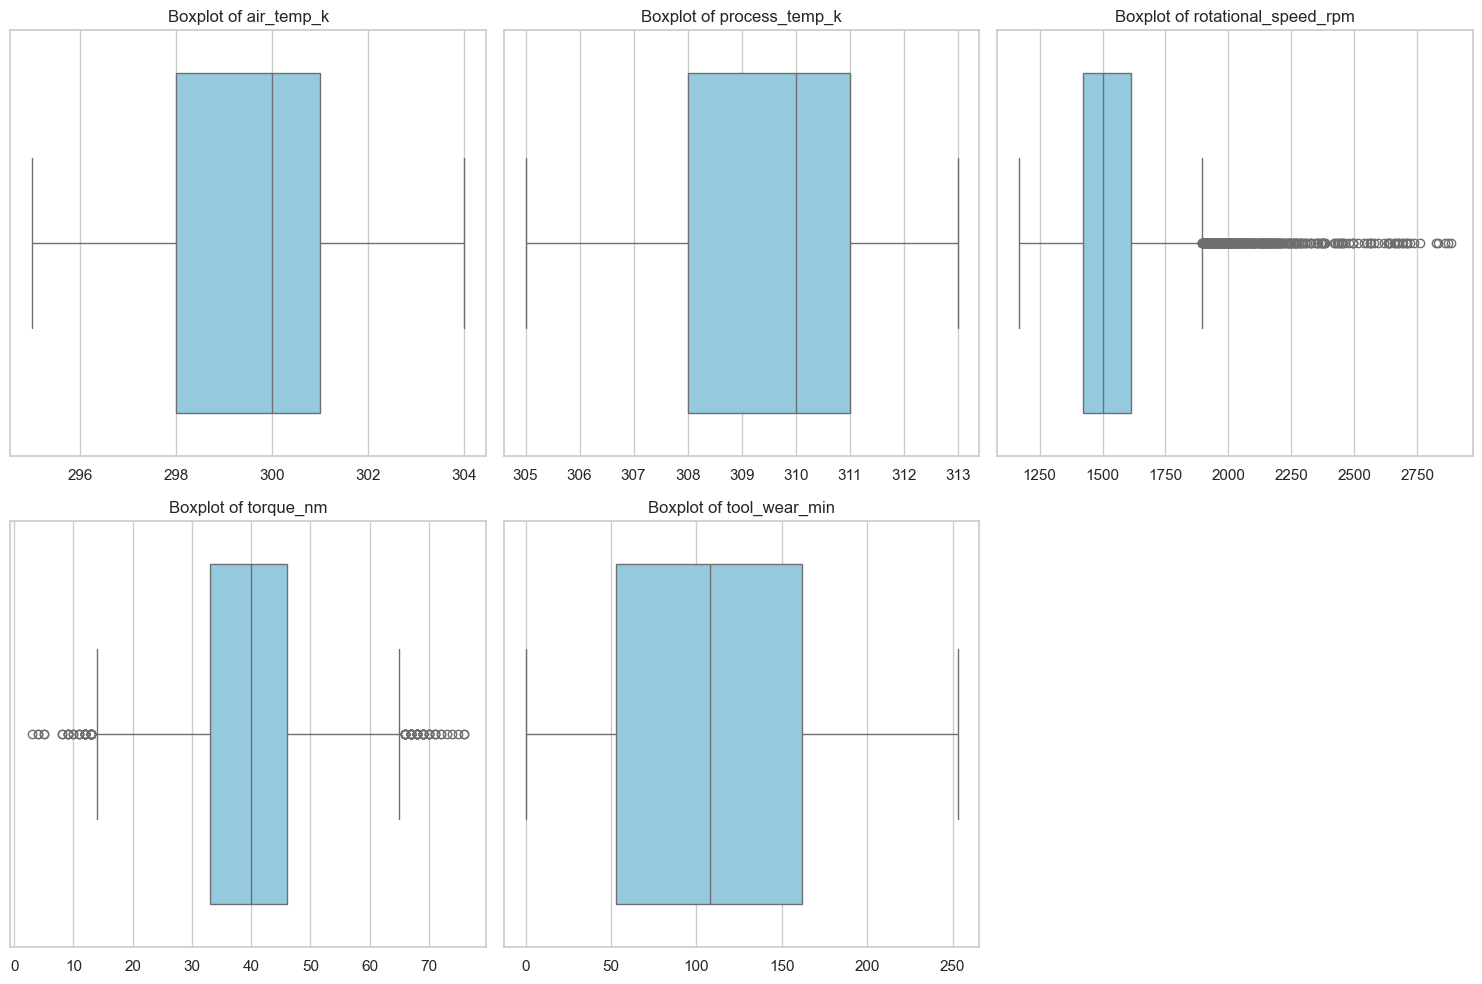

In [131]:
# Crear un diagrama de caja para visualizar la distribución de cada variable medida y detectar valores atípicos
### YOUR CODE HERE ###
# 1. Definir la lista de columnas numéricas
cols_numericas = ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']

# 2. Configurar la cuadrícula de gráficos (ej: 2 filas y 3 columnas)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten() # Aplana la matriz de ejes para iterar fácilmente

# 3. Iterar y graficar
for i, col in enumerate(cols_numericas):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('') # Limpia el eje X para mayor claridad

# 4. Eliminar el último gráfico sobrante (ya que son 5 variables en una red de 6)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Analisis

Se pueden apreciar valores atipicos en las variables de velocidad rotacional por encima del limite superior, y Torque en ambos lados del diagrama de caja. Esto se puede deber debido a que habra ciertas piezas que requiern una mayor velocidad como para el acabado y otras un desbaste (menor velocidad mayor toque), y otra es que cuando ocurren fallas por potencia (PWF) la velocidad aumenta de forma desmedida. El analisis de los valores átipicos de Torque pueden tener la misma causalidad.

In [132]:
#1. Definir qué es un outlier de velocidad (Estadística pura)
Q1 = df['rotational_speed_rpm'].quantile(0.25)
Q3 = df['rotational_speed_rpm'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# 2. Aislar los casos que superan el límite
outliers_velocidad = df[df['rotational_speed_rpm'] > limite_superior]

# 3. ¿Cuántos de estos son realmente fallas?
total_outliers = len(outliers_velocidad)
fallas_reales = outliers_velocidad[outliers_velocidad['machine_failure'] == 1].shape[0]

print(f"Total de valores atípicos en velocidad: {total_outliers}")
print(f"De esos, ¿cuántos causaron falla?: {fallas_reales}")
print(f"Porcentaje de falla en outliers: {(fallas_reales/total_outliers)*100:.2f}%")

#1. Definir qué es un outlier de Torque (Estadística pura)
Q1 = df['torque_nm'].quantile(0.25)
Q3 = df['torque_nm'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# 2. Aislar los casos que superan el límite
outliers_torque = df[df['torque_nm'] > limite_superior]

# 3. ¿Cuántos de estos son realmente fallas?
total_outliers = len(outliers_torque)
fallas_reales = outliers_torque[outliers_torque['machine_failure'] == 1].shape[0]

print(f"Total de valores atípicos en torque: {total_outliers}")
print(f"De esos, ¿cuántos causaron falla?: {fallas_reales}")
print(f"Porcentaje de falla en outliers: {(fallas_reales/total_outliers)*100:.2f}%")


Total de valores atípicos en velocidad: 418
De esos, ¿cuántos causaron falla?: 35
Porcentaje de falla en outliers: 8.37%
Total de valores atípicos en torque: 50
De esos, ¿cuántos causaron falla?: 42
Porcentaje de falla en outliers: 84.00%


Luego de determinar la cantidad exacta de valores átipicos y si aparecen cuando se produjo una falla o no, podemos suponer que los valores átipicos de la variable Torque estan muy ralacionados con los fallos en la máquina, mientras que los de la velocidad rotacional tienen poca relación.

## ANALIZAR
Continuar con el EDA (Analisis Exploratorio de los Datos)

### **Preguntas que responder en esta etapa:**
- ¿Que se observa acerca de la relacion entre las distintas variables?
- ¿Qué se observa de la distribucion de los datos?
- ¿Que transformaciones realizaremos en los datos?¿Por qué elegimos estas transformaciones?
- ¿Cuales son algunos supuestos del EDA antes de la construccion del modelo?
- ¿QUe recursos utilice para completar esta etapa?
- ¿Tuvimos alguna consideracion ética en esta etapa?


### Balance de Fallas



In [61]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
Fallas = df['machine_failure'].value_counts()
print(Fallas)
# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
porcentages = df['machine_failure'].value_counts(normalize=True) * 100
print(porcentages)
#Agrupar por los tipos de falla
Fallas_tipos = df[['tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure', 'random_failure']].sum()
print(Fallas_tipos)
#Obtener porcentajes de cada tipo de falla
porcentajes_tipos = (Fallas_tipos / Fallas_tipos.sum()) * 100
print(porcentajes_tipos)

machine_failure
0    9661
1     339
Name: count, dtype: int64
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64
tool_wear_failure            46
heat_dissipation_failure    115
power_failure                95
overstrain_failure           98
random_failure               19
dtype: int64
tool_wear_failure           12.332440
heat_dissipation_failure    30.831099
power_failure               25.469169
overstrain_failure          26.273458
random_failure               5.093834
dtype: float64


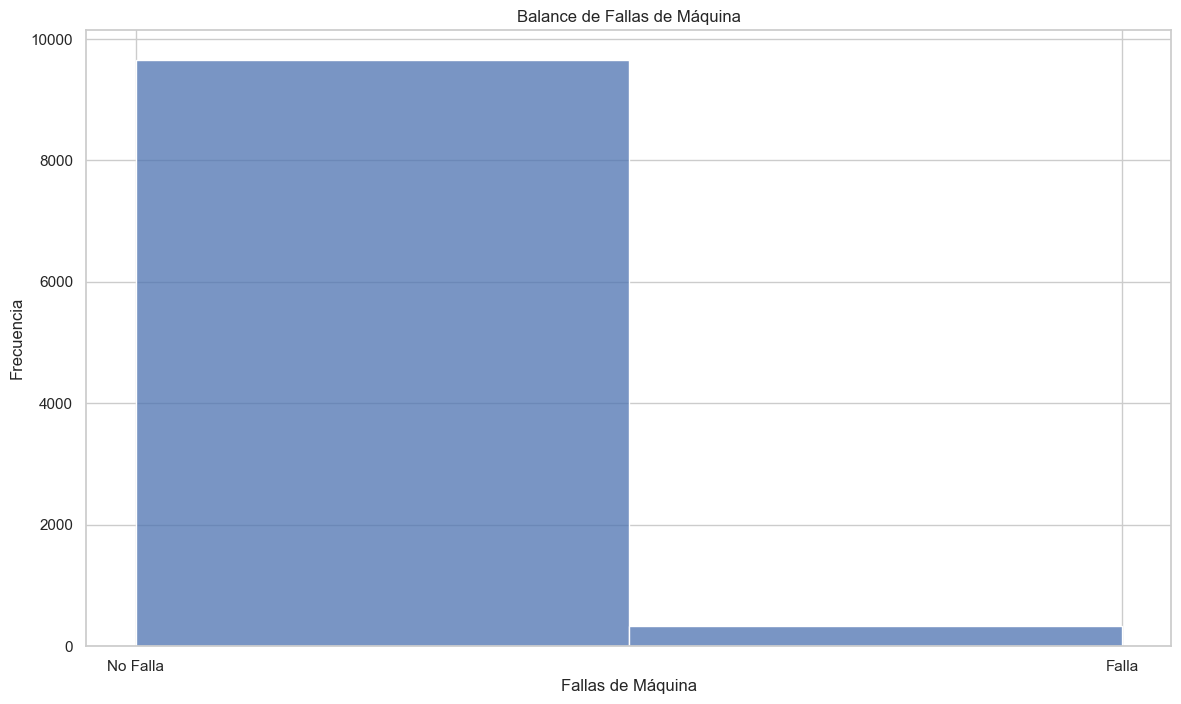

In [62]:
# Visualizar el balance de machine_failure
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='machine_failure',bins=2)
#colocar títulos y etiquetas
plt.title('Balance de Fallas de Máquina')
plt.xlabel('Fallas de Máquina')
plt.ylabel('Frecuencia')
#colocar falla y no falla en el eje x
plt.xticks([0, 1], ['No Falla', 'Falla'])


plt.show()

Analizando lo obtenido: Vemos que la proporcion de fallas es menor al 4% del total de productos, un DESBALANCE muy grande en la variable objetivo. Luego de acuerdo a los tipos de fallas, las fallas random ocupan un porcentaje muy menor, eso es bueno debido a que no conocemos las causas que las provocan.

### Transformaciones
Vamos a crear nuevas columnas para poder luego visualizar las distintas correlaciones con las fallas.

In [63]:
# Creamos una columna nueva que indique el delta de temperatura entre proceso y aire
df['temp_delta'] = df['process_temp_k'] - df['air_temp_k'] 

# Creamos otra columna que indique la potencia (rpm * torque)
df['power'] = df['torque_nm'] * df['rotational_speed_rpm'] * (2 * np.pi / 60)

# Creamos otra columna que indique el producto entre el desgaste y el torque
df['wear_torque_product'] = df['tool_wear_min'] * df['torque_nm']

df.head()

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure,temp_delta,power,wear_torque_product
0,1,M14860,M,298.0,308.0,1551.0,42.0,0.0,0,0,0,0,0,0,10.0,6821.654288,0.0
1,2,L47181,L,298.0,308.0,1408.0,46.0,3.0,0,0,0,0,0,0,10.0,6782.489100,138.0
2,3,L47182,L,298.0,308.0,1498.0,49.0,5.0,0,0,0,0,0,0,10.0,7686.639465,245.0
3,4,L47183,L,298.0,308.0,1433.0,39.0,7.0,0,0,0,0,0,0,10.0,5852.472954,273.0
4,5,L47184,L,298.0,308.0,1408.0,40.0,9.0,0,0,0,0,0,0,10.0,5897.816608,360.0


### Analisis de linealidad logit
Analizar si las variables dependientes tiene capacidad predictiva en regresion logistica.

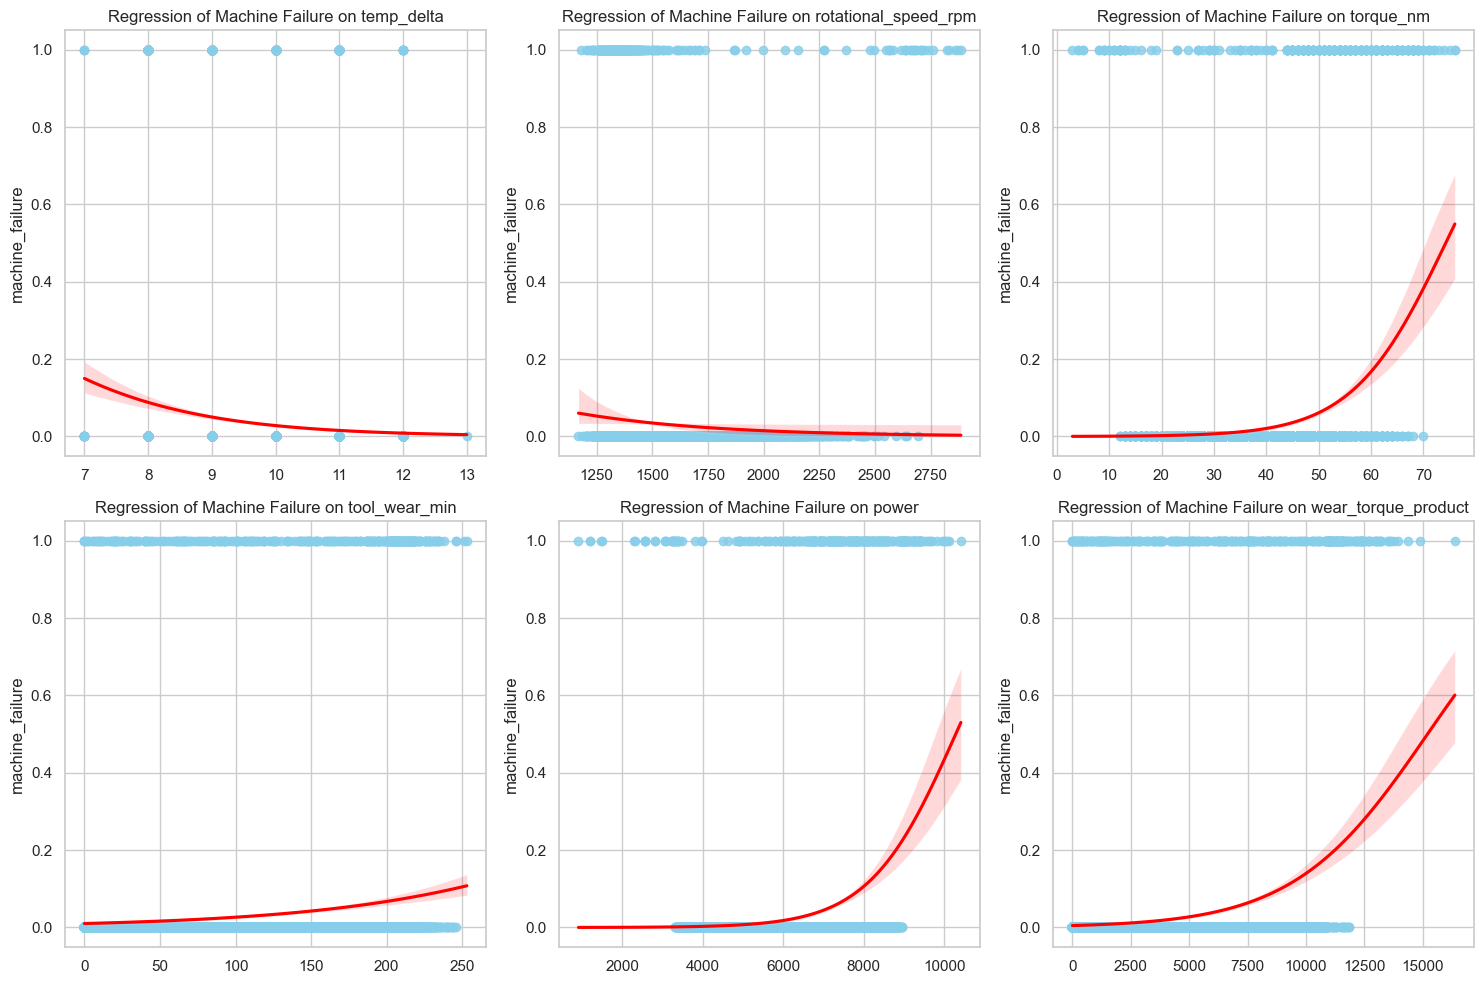

In [64]:
# Crear un diagrama de regresion para visualizar si hay correlación entre las variables numéricas y machine_failure
# 1. Definir la lista de columnas numéricas
cols_numericas = ['temp_delta','rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'power', 'wear_torque_product']

# 2. Configurar la cuadrícula de gráficos (ej: 2 filas y 3 columnas)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten() # Aplana la matriz de ejes para iterar fácilmente

# 3. Iterar y graficar
for i, col in enumerate(cols_numericas):
    sns.regplot(x=df[col], y=df['machine_failure'], ax=axes[i], color='skyblue',line_kws={"color": "red"},logistic=True)
    axes[i].set_title(f'Regression of Machine Failure on {col}')
    axes[i].set_xlabel('') # Limpia el eje X para mayor claridad
   
plt.tight_layout() 
plt.show()

Se puede apreciar que las relaciones son No Lineales, ninguna variable sigue la funcion sigmoide (curva en forma de S). Por lo tanto se descarta el uso de Regresion Logistica.

### Visualizar correlaciones entre las variables

#### Para la falla de TWF

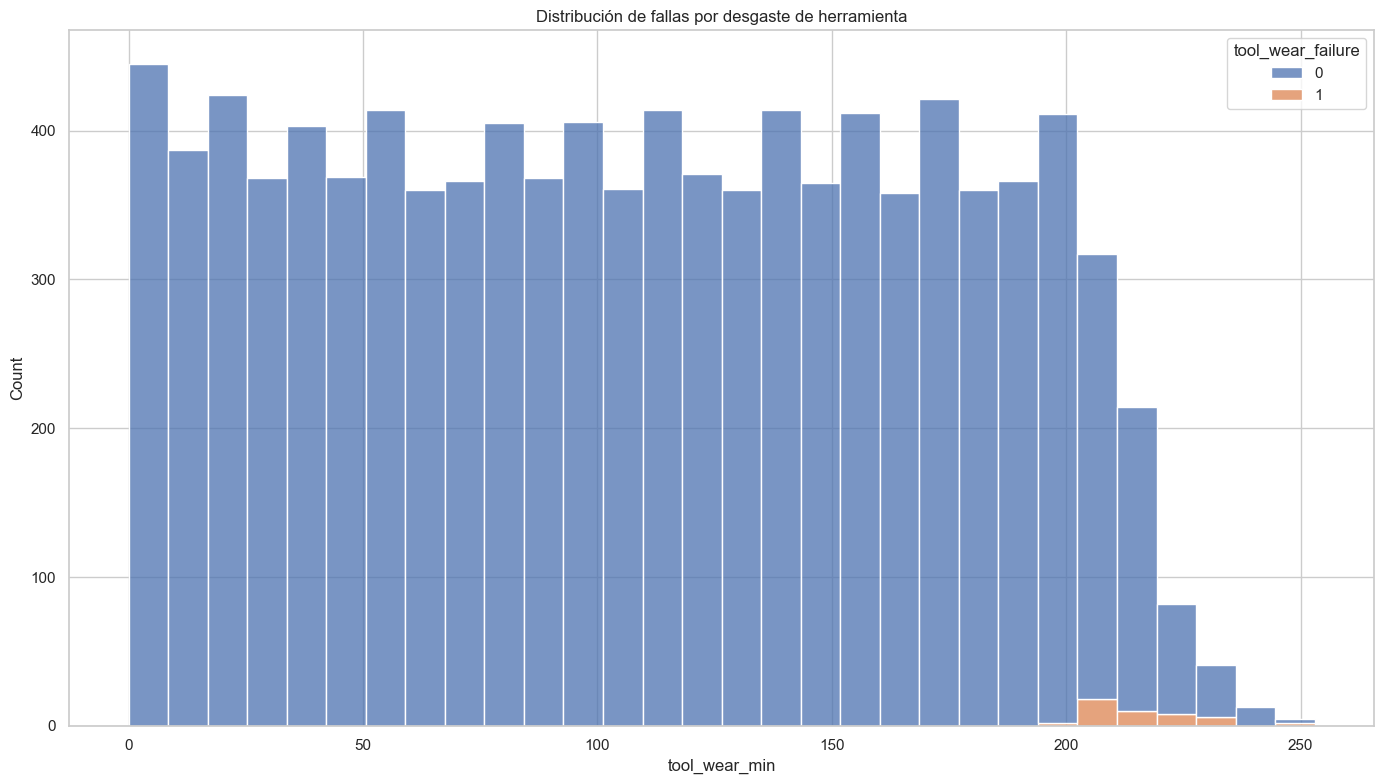

,tool_wear_min,tool_wear_failure
0,"(-0.253, 16.867]",0
1,"(16.867, 33.733]",0
2,"(33.733, 50.6]",0
3,"(50.6, 67.467]",0
4,"(67.467, 84.333]",0
5,"(84.333, 101.2]",0
6,"(101.2, 118.067]",0
7,"(118.067, 134.933]",0
8,"(134.933, 151.8]",0
9,"(151.8, 168.667]",0


In [109]:
# Visualizar la correlacion entre tool_wear_min y tool_wear_failure
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='tool_wear_min', hue='tool_wear_failure', multiple='stack', bins=30)
plt.title('Distribución de fallas por desgaste de herramienta')
plt.show()
#agrupar como se distribuye el tool_wear_failure por intervalos de desgaste
# Agregamos observed=True para ocultar bins vacíos
df_grouped = df.groupby(pd.cut(df['tool_wear_min'], bins=15), observed=True)['tool_wear_failure'].sum().reset_index()
df_grouped



Los fallos por desgaste ocurren a un tiempo de uso mayor a 200 minutos.

#### Para la falla HDF

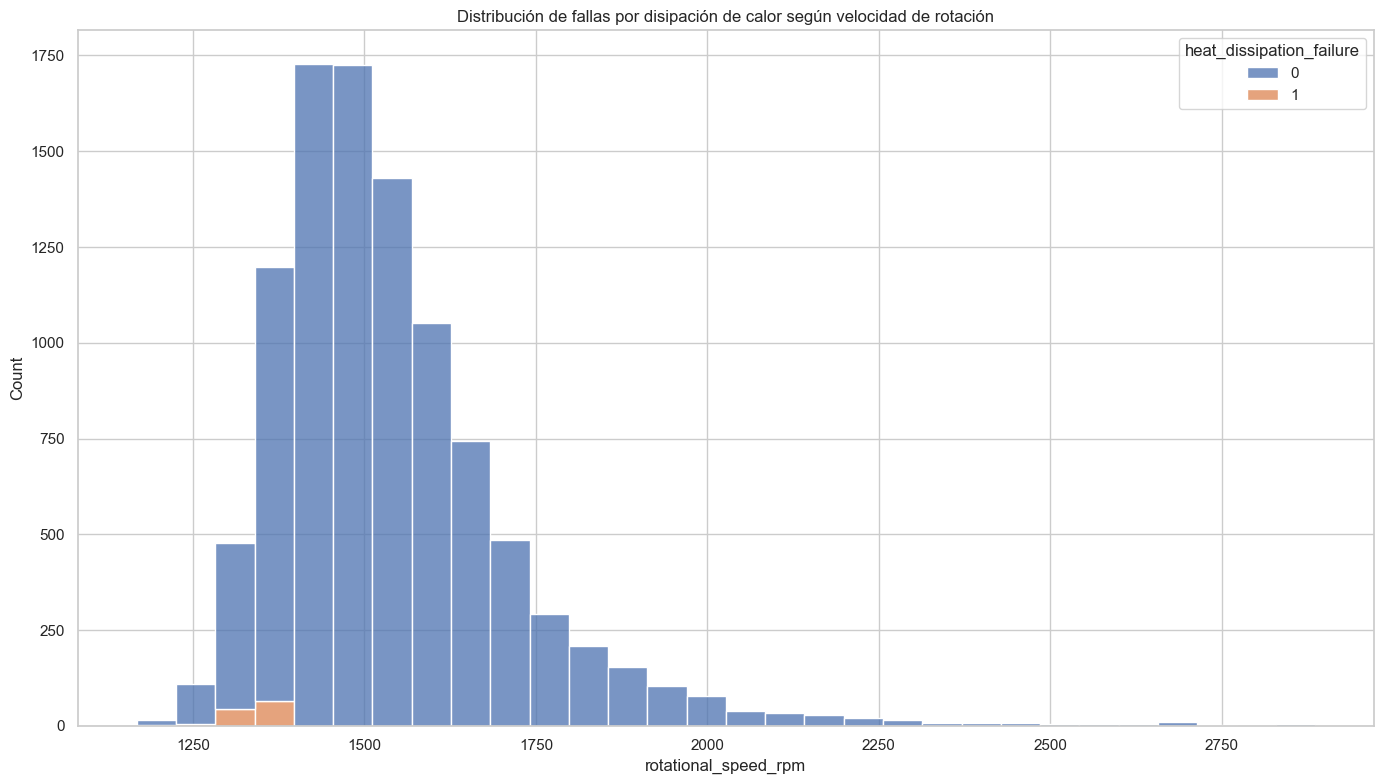

,rotational_speed_rpm,heat_dissipation_failure
0,"(1166.282, 1282.533]",8
1,"(1282.533, 1397.067]",107
2,"(1397.067, 1511.6]",0
3,"(1511.6, 1626.133]",0
4,"(1626.133, 1740.667]",0
5,"(1740.667, 1855.2]",0
6,"(1855.2, 1969.733]",0
7,"(1969.733, 2084.267]",0
8,"(2084.267, 2198.8]",0
9,"(2198.8, 2313.333]",0


In [110]:
# Visualizar la correlacion entre rotational_speed_rpm y heat_dissipation_failure
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='rotational_speed_rpm', hue='heat_dissipation_failure', multiple='stack', bins=30)
plt.title('Distribución de fallas por disipación de calor según velocidad de rotación')
plt.show()
#agrupar como se distribuye el heat_dissipation_failure por la velocidad de rotación
df_grouped = df.groupby(pd.cut(df['rotational_speed_rpm'], bins=15),observed=True)['heat_dissipation_failure'].sum().reset_index()
df_grouped


Las fallas por disipacion de calor ocurren para velocidades de rotacion inferiores a 1400 rpm.

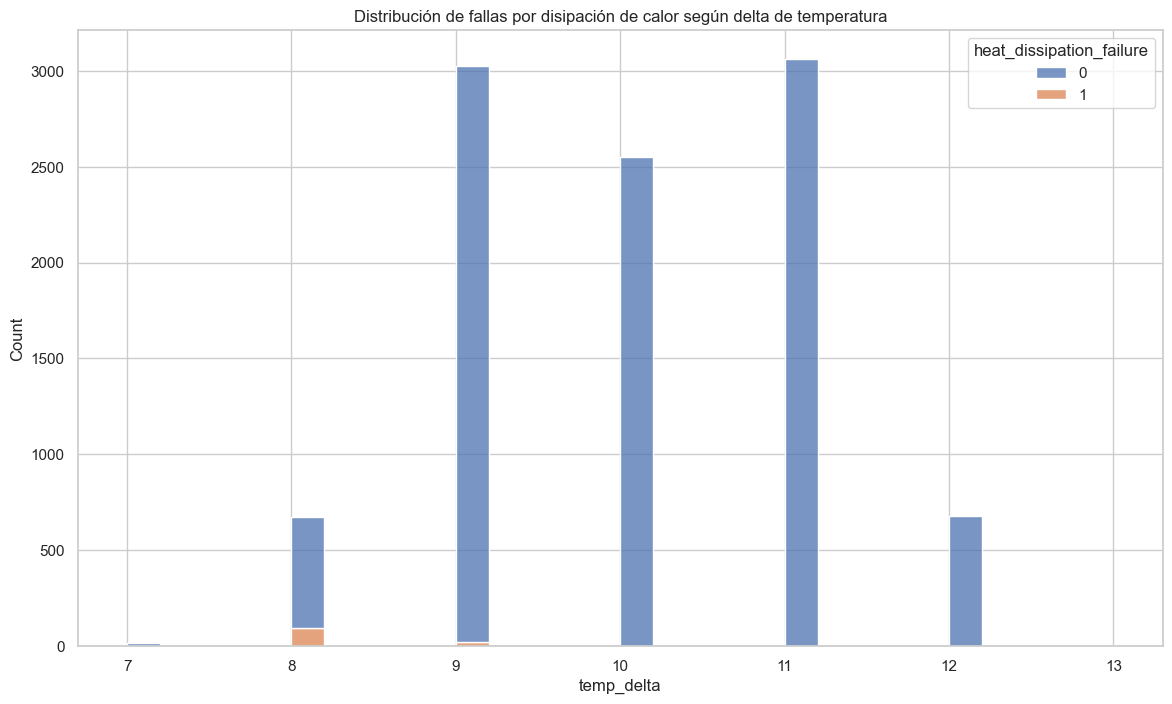

,temp_delta,machine_failure,heat_dissipation_failure
0,7.0,3,2
1,8.0,105,94
2,9.0,88,19
3,10.0,62,0
4,11.0,73,0
5,12.0,8,0
6,13.0,0,0


In [67]:
# Visualizar la correlacion entre tem_delta y heat_dissipation_failure
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='temp_delta', hue='heat_dissipation_failure', multiple='stack', bins=30)
plt.title('Distribución de fallas por disipación de calor según delta de temperatura')
plt.show()
#agrupar como se distribuye el heat_dissipation_failure por el delta de temperatura
df_grouped = df.groupby('temp_delta')[['machine_failure','heat_dissipation_failure']].sum().reset_index()
df_grouped


La falla HDF se presenta mayoritariamente para un delta de temperatura entre el aire y el proceso menor a 9 graados kelvin.

#### Para la falla PWF

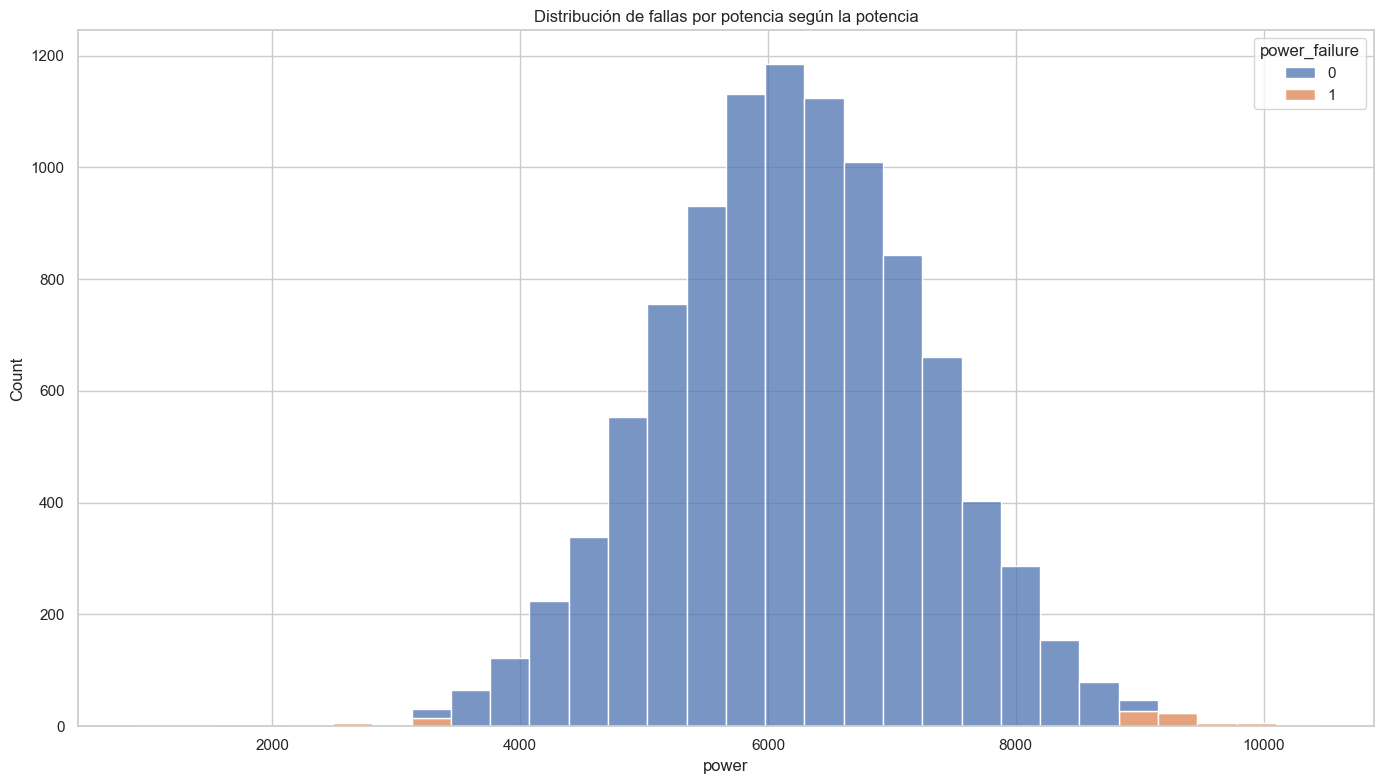

                   power  power_failure
0    (897.156, 1540.511]              5
1   (2174.359, 2808.207]              8
2   (2808.207, 3442.055]             17
3   (3442.055, 4075.902]              1
4    (4075.902, 4709.75]              0
5    (4709.75, 5343.598]              0
6   (5343.598, 5977.446]              0
7   (5977.446, 6611.293]              0
8   (6611.293, 7245.141]              0
9   (7245.141, 7878.989]              0
10  (7878.989, 8512.836]              0
11  (8512.836, 9146.684]             27
12  (9146.684, 9780.532]             30
13  (9780.532, 10414.38]              7


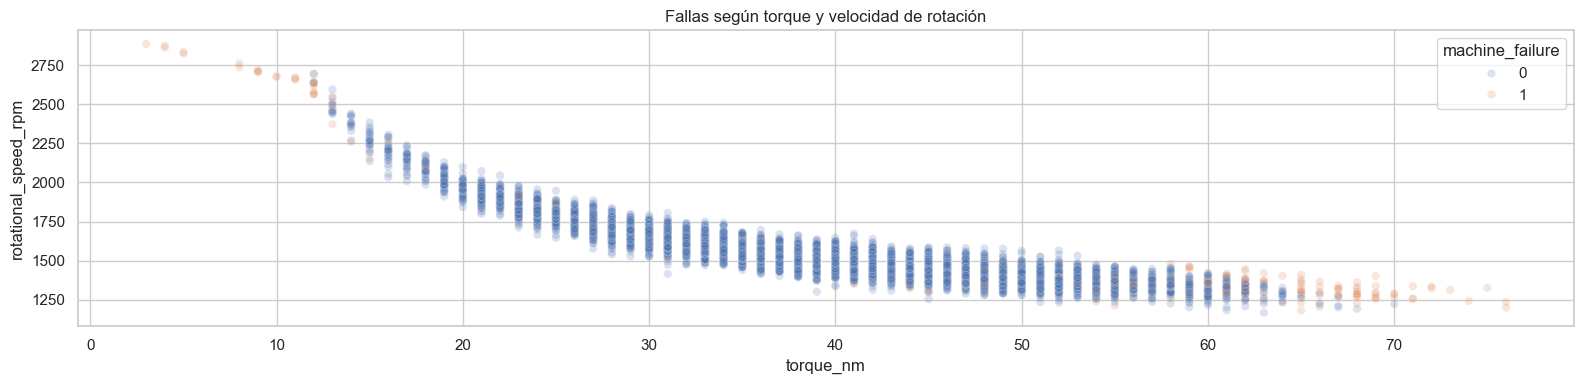

In [111]:
# Visualizar la correlacion entre power y power_failure
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='power', hue='power_failure', multiple='stack', bins=30)
plt.title('Distribución de fallas por potencia según la potencia')
plt.show()
#agrupar como se distribuye el power_failure por intervalos de power
df_grouped = df.groupby(pd.cut(df['power'], bins=15), observed=True)['power_failure'].sum().reset_index()
print(df_grouped)
# Crear scatterplot de `torque_nm` versus `rotational_speed_rpm`, comparando las fallas
plt.figure(figsize=(16, 4))
sns.scatterplot(data=df, x='torque_nm', y='rotational_speed_rpm', hue='machine_failure', alpha=0.2)
plt.title('Fallas según torque y velocidad de rotación')
plt.show()


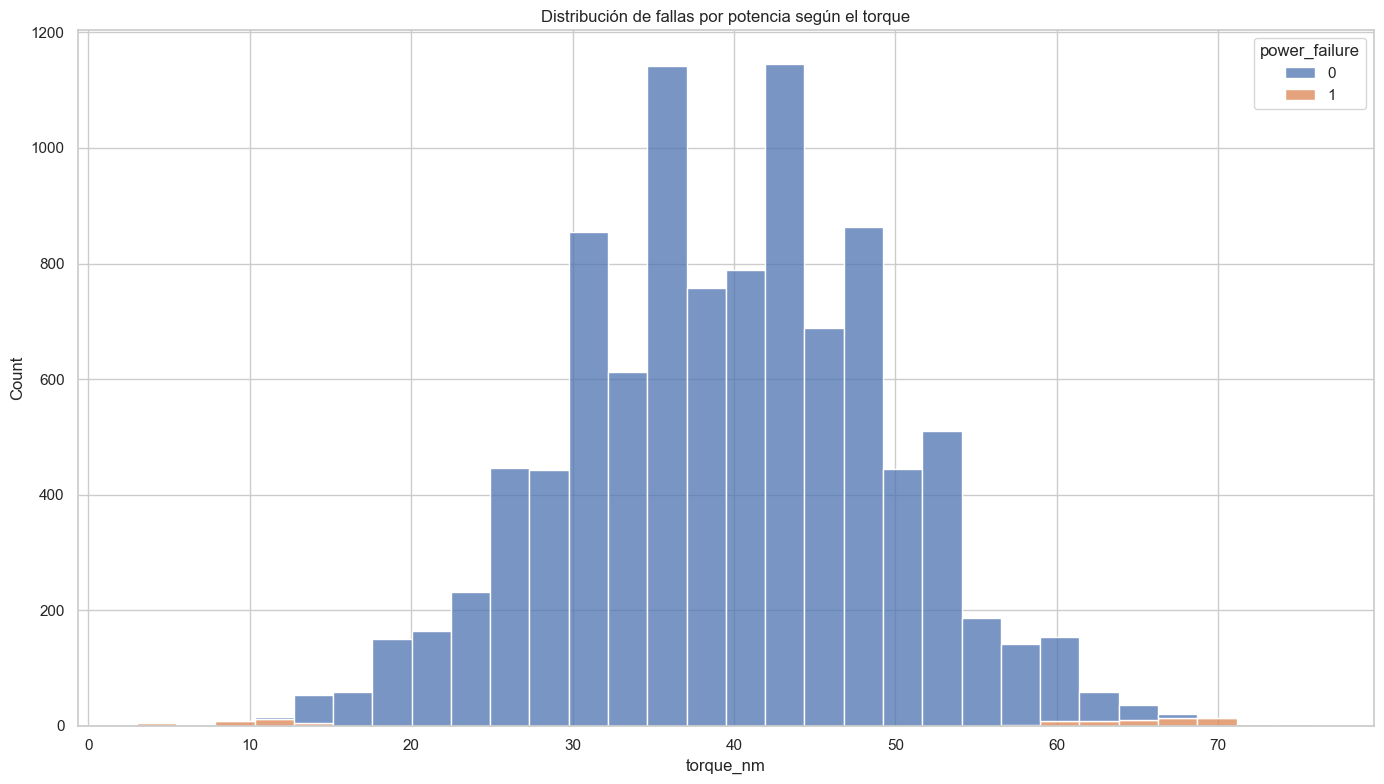

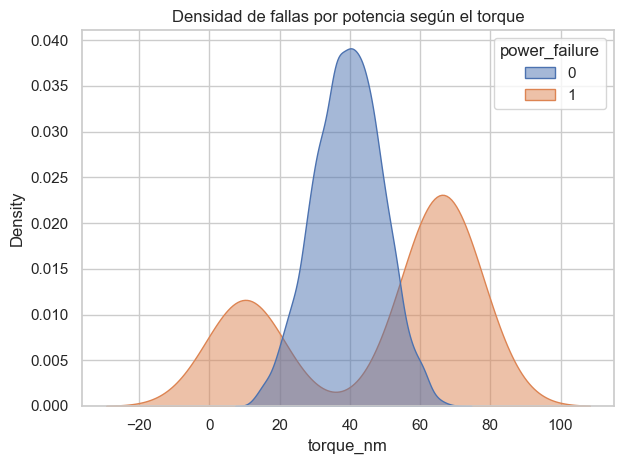

           torque_nm  power_failure
0     (2.927, 7.867]              5
1    (7.867, 12.733]             20
2     (12.733, 17.6]              6
3     (17.6, 22.467]              0
4   (22.467, 27.333]              0
5     (27.333, 32.2]              0
6     (32.2, 37.067]              0
7   (37.067, 41.933]              0
8     (41.933, 46.8]              0
9     (46.8, 51.667]              0
10  (51.667, 56.533]              0
11    (56.533, 61.4]             10
12    (61.4, 66.267]             20
13  (66.267, 71.133]             27
14    (71.133, 76.0]              7


In [112]:
# Visualizar la correlacion entre torque y power_failure
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='torque_nm', hue='power_failure', multiple='stack', bins=30)
plt.title('Distribución de fallas por potencia según el torque')
plt.show()
sns.kdeplot(data=df, x='torque_nm', hue='power_failure', fill=True, common_norm=False, alpha=0.5)
plt.title('Densidad de fallas por potencia según el torque')
plt.show()
#agrupar como se distribuye el power_failure por intervalos de torque
df_grouped = df.groupby(pd.cut(df['torque_nm'], bins=15), observed=True)['power_failure'].sum().reset_index()
print(df_grouped)

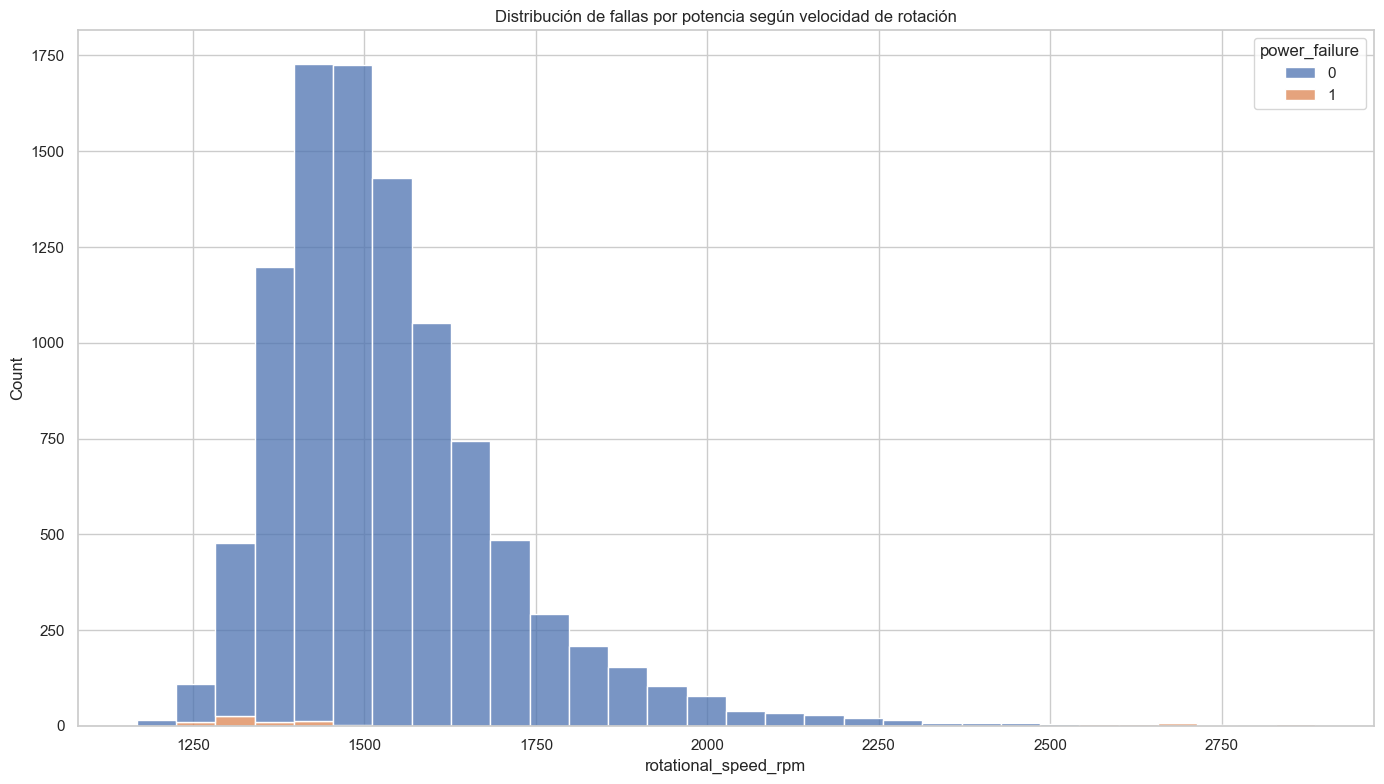

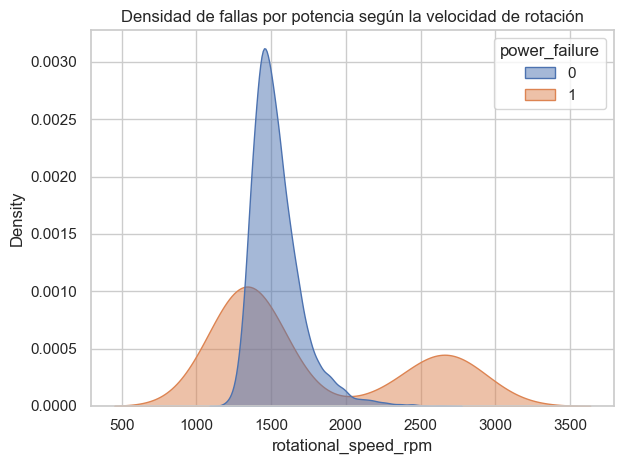

    rotational_speed_rpm  power_failure
0   (1166.282, 1282.533]             12
1   (1282.533, 1397.067]             36
2     (1397.067, 1511.6]             16
3     (1511.6, 1626.133]              0
4   (1626.133, 1740.667]              0
5     (1740.667, 1855.2]              0
6     (1855.2, 1969.733]              0
7   (1969.733, 2084.267]              0
8     (2084.267, 2198.8]              1
9     (2198.8, 2313.333]              1
10  (2313.333, 2427.867]              1
11    (2427.867, 2542.4]              2
12    (2542.4, 2656.933]              9
13  (2656.933, 2771.467]             12
14    (2771.467, 2886.0]              5


In [113]:
# Visualizar la correlacion entre rotational_speed_rpm y power_failure
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='rotational_speed_rpm', hue='power_failure', multiple='stack', bins=30)
plt.title('Distribución de fallas por potencia según velocidad de rotación')
plt.show()
sns.kdeplot(data=df, x='rotational_speed_rpm', hue='power_failure', fill=True, common_norm=False, alpha=0.5)
plt.title('Densidad de fallas por potencia según la velocidad de rotación')
plt.show()
#agrupar como se distribuye el power_failure por la velocidad de rotación
df_grouped = df.groupby(pd.cut(df['rotational_speed_rpm'], bins=15), observed=True)['power_failure'].sum().reset_index()
print(df_grouped)



Las Fallas por PWF se encuentran fuera del rango de torque de 18 a 57 Nm y del rango de velocidad de rotacion de 1511 a 2000 rpm

#### Para la falla de OSF

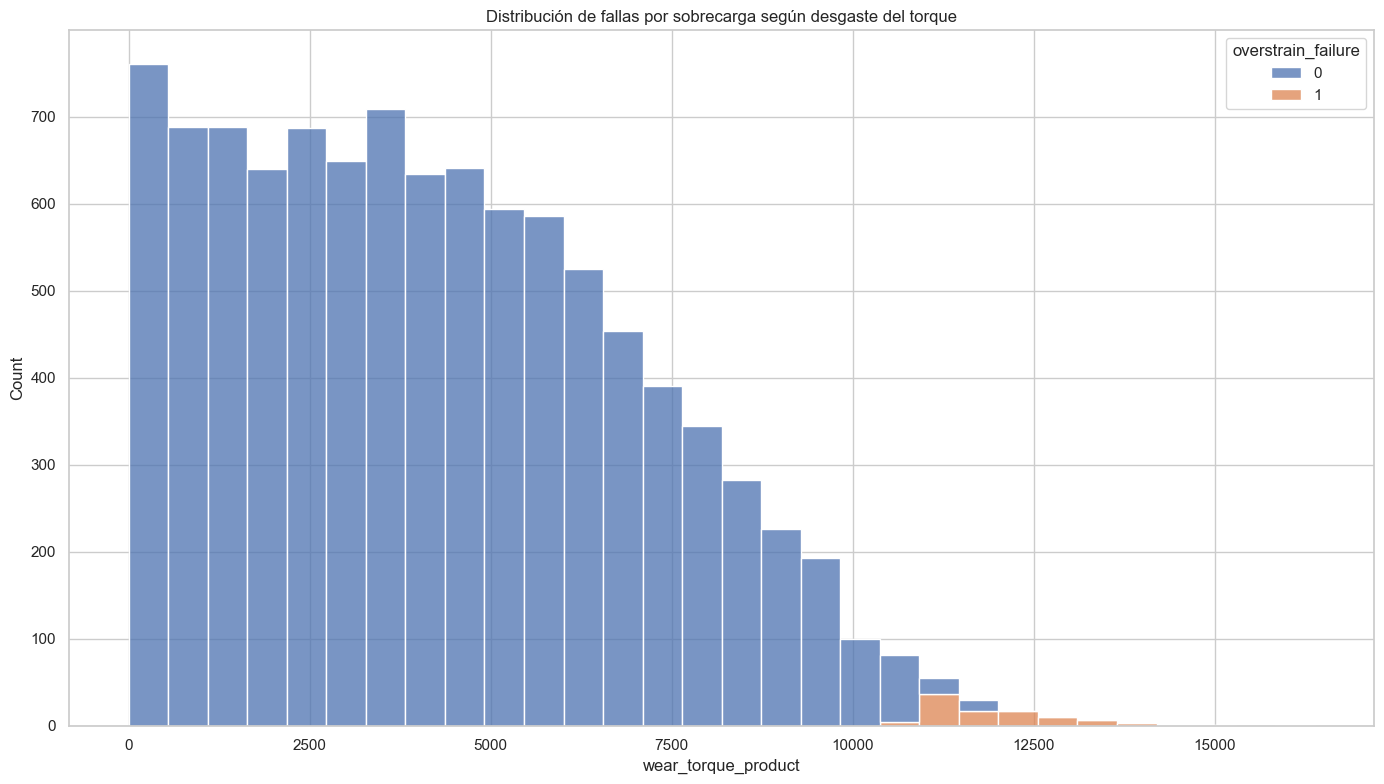

,wear_torque_product,overstrain_failure
0,"(-16.38, 1092.0]",0
1,"(1092.0, 2184.0]",0
2,"(2184.0, 3276.0]",0
3,"(3276.0, 4368.0]",0
4,"(4368.0, 5460.0]",0
5,"(5460.0, 6552.0]",0
6,"(6552.0, 7644.0]",0
7,"(7644.0, 8736.0]",0
8,"(8736.0, 9828.0]",0
9,"(9828.0, 10920.0]",5


In [114]:
# Visualizar la correlacion entre wear_torque_product y overstrain_failure
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='wear_torque_product', hue='overstrain_failure', multiple='stack', bins=30)
plt.title('Distribución de fallas por sobrecarga según desgaste del torque')
plt.show()
#agrupar como se distribuye el overstrain_failure por el desgaste del torque
df_grouped = df.groupby(pd.cut(df['wear_torque_product'], bins=15), observed=True)['overstrain_failure'].sum().reset_index()
df_grouped

La falla de OSF ocurre para valores del producto entre el uso y el torque, mayores a 980 minNm.

#### Mapa de correlaciones entre las distintas variables del dataset

Text(0.5, 1.0, 'Mapa de calor de Correlacion')

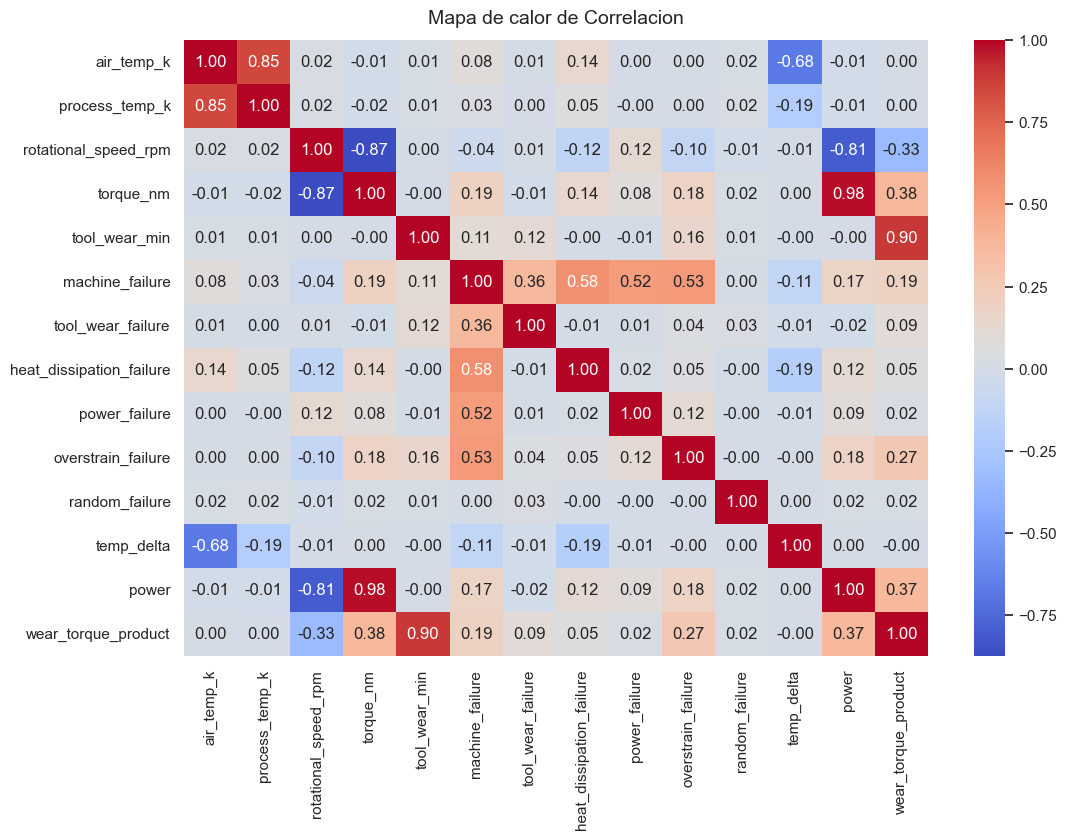

In [72]:
#Visualizar la colinealidad de las variables con un heatmap de correlación(solo numéricas)
plt.figure(figsize=(12, 8))
numeric_df0 = df.select_dtypes(include=[np.number])
heatmap = sns.heatmap(numeric_df0.corr(), annot=True, fmt=".2f", cmap='coolwarm')
heatmap.set_title('Mapa de calor de Correlacion', fontdict={'fontsize':14}, pad=12)

Analizando el grafico: 

Empezando con los sensores de temperatura tienen una colinealidad fuerte, por lo que podemos considerar informacion redundante, validando nuestra nueva variable temp_delta.

Las variables de velocidad rotacional y de toque tambien presentan gran colinealidad. Lo destacable es la correlacion del 0.98 de toque y power(potencia), la variables es practicamente un clon de torque, a pesar de esto no descartaremos ninguna, los modelos de ML son capaces de elgir entre cual quedarse y no los afecta, a diferencia de los modelos mas simples.

Viendo las varibles de fallas, logicamente la variable machine_failuere (falla mecanica) tiene correlacion con las demas fallas,a excepcion de la random_failure (falla aleatoria), la cual no tiene correlacion destacable con ninguna variable del mapa, si sumamos a esto a que representa un porcentaje muy pequeño dentro de los tipos de falla, podemos descartarla a la hora de constrouir el modelo.

La falla general machine_failure tiene como sensor estrella al torque_nm con una correlacion de 0.19, seguido por el tool_wear_min y el de temperatura.

Analizando la variable creada wear_torque_product, tiene gran correlacion con tool_wear_min, pero viendo el tipo de falla overstrain_failure la variable con mayor correlacion es wear_torque_product (0.27), validando la nueva variable.

## Construcción
- Determinar el modelo mas apropiado
- Construir el modelo
- Confirmar suposiciones del modelo
- Evaluar los resultados del modelo para determinar que tan bien ajusto los datos


### Reflexionar sobre estas dudas al completar esta etapa

- ¿Notas algo raro?
- ¿Cuales son la variables independientes que elegimos y por que?
- ¿Se cumplen todos los supuestos?
- ¿Que tan bien ajusta los datos el modelo?
- ¿Podemos mejorar el modelo? ¿Hay algo que cambiariamos sobre el modelo?
- ¿Que recursos utilizamos realizando esta etapa? 
- ¿Tuvimos alguna consideracion etica al realizar esta etapa?


### Elección de los modelos

Resumen de la elección:
- Tipo: Supervisado (Tenemos etiquetas).
- Target: Clasificación (falla o no falla, 1 o 0)
- Relación No Lineal (fallas de maquina complejas)--> Conclusion del EDA
- Prioridad Interpretabilidad (causa de la falla) --> Modelo que explicar las causas (random Forest)
- Manejo del desbalance
- Eleccion: Random Forest y XGBoost


### Construir un modelo Random Forest


Nuestra base de datos cuenta con mas de una variable objetivo, tenemos falla mecanica (machine_failure) que es la falla general y luego los tipos de fallas de desgaste de la herramienta (tool_wear_failure), por disipacion de calor (heat_dissipation_failure), por potencia(power_failure), por sobrecarga(overstrain_failure) o falla aleatoria (random_failure). 

En nuestro dataset cada tipo de falla aparece por separado, pero en un caso real pueden ocurrir de forma simultanea, por esto tomaremos algunas medidas para realizar el modelo.

Primero modelaremos con la variable machine_failure 

Antes de comenzar modificaremos la variable "type" que indica la calidad con letras (L, M y H) siendo una variable multiclase, lo que para el modelo debemos modificar (el modelo no entiende cuanto vale cada letra), al ser una variable de calidad es mas conveniente utilizar una codificacion ordinal, como la siguiente:

In [133]:
# Definimos el orden lógico: Low=0, Medium=1, High=2
orden_calidad = {'L': 0, 'M': 1, 'H': 2}

# Aplicamos la transformación antes de dividir los datos
df['type_encoded'] = df['type'].map(orden_calidad)

# Ahora eliminamos la columna original de texto
df = df.drop(columns=['type'])

In [134]:
#Preparar variables X e Y

#Descartamos random_failure segun el analisis previo
target_cols = ['tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure']
#La variable 'machine_failure' es la suma de las anteriores no se usa como predictor
features_to_drop = ['udi', 'product_id', 'random_failure', 'machine_failure'] + target_cols

X = df.drop(columns=features_to_drop)
y = df[target_cols]


In [135]:
# Dividimos el dataset en entrenamiento (Train) y prueba (Test)
#Usamos un split aleatorio (para multietiqueta real se usaría iterative stratification, 
# pero para este volumen de datos train_test_split es suficiente)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Tamaño de X_train: {X_train.shape}, Tamaño de X_test: {X_test.shape}")


Tamaño de X_train: (8000, 6), Tamaño de X_test: (2000, 6)


#### Creamos el Modelo Random Forest
Aclaracion: Los scripts de los modelos se encuentran en src/models

Usamos como metricas para medir el rendimiento del modelo F1(balance entre precisión y recall), recall(para medir la cantidad de fallos predichos) y presicion.

In [149]:
from src.models.train_model import train_multioutput_rf_gridsearch

rf_gridsearch = train_multioutput_rf_gridsearch(X_train, y_train)


2026-01-08 20:26:21,047 - INFO - No se proporcionó param_grid, usando configuración por defecto.
2026-01-08 20:26:21,048 - INFO - Configurando el modelo MultiOutput RandomForest...
2026-01-08 20:26:21,050 - INFO - Iniciando GridSearchCV con 4 folds y optimizando F1-Macro...


Fitting 4 folds for each of 48 candidates, totalling 192 fits


2026-01-08 20:57:28,096 - INFO - Entrenamiento finalizado con éxito.
2026-01-08 20:57:28,098 - INFO - Mejores parámetros encontrados: {'estimator__max_depth': 20, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 500}
2026-01-08 20:57:28,100 - INFO - Mejor Score F1 (CV): 0.5529


#### Definimos una funcion para mostrar las metricas del modelo

#### Mostramos los resultados y los parametros del mejor modelo

In [150]:
from src.models.evaluate.evaluate_model import get_scores 

# 6. Resultados
print(f"\nMejores parámetros encontrados: {rf_gridsearch.best_params_}")
print(f"Mejor puntuación F1: {rf_gridsearch.best_score_:.4f}")
rf_test_scores = get_scores('random forest test', rf_gridsearch, X_test, y_test)
rf_test_scores


Mejores parámetros encontrados: {'estimator__max_depth': 20, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 500}
Mejor puntuación F1: 0.5529


,model,precision,recall,f1
0,random forest test,0.677044,0.536415,0.598427


In [151]:
rf_best = rf_gridsearch.best_estimator_
y_preds = rf_best.predict(X_test)

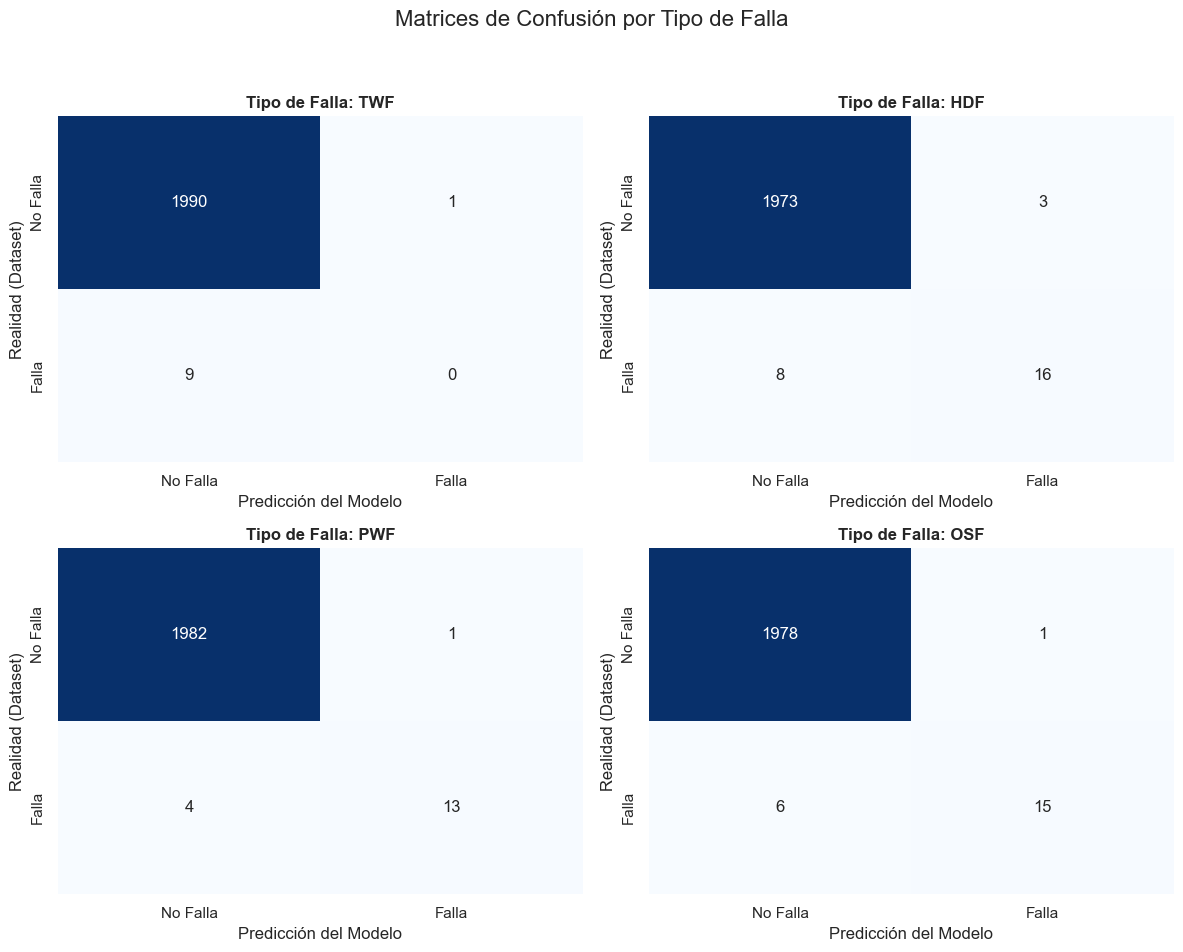

In [152]:

# 1. Calculamos las matrices (y_test e y_pred vienen del modelo anterior)
matrices = multilabel_confusion_matrix(y_test, y_preds)
target_cols = ['TWF', 'HDF', 'PWF', 'OSF']

# 2. Configuramos la figura (2 filas y 2 columnas para las 4 fallas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
fig.suptitle('Matrices de Confusión por Tipo de Falla', fontsize=16)

# labels para los ejes
labels = ['No Falla', 'Falla']

# 3. Iteramos para graficar cada matriz
for i, ax in enumerate(axes.flat):
    sns.heatmap(matrices[i], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False)
    
    ax.set_title(f'Tipo de Falla: {target_cols[i]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción del Modelo')
    ax.set_ylabel('Realidad (Dataset)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

📊 Gráfico guardado en: reports/figures\feat_import_TWF
📊 Gráfico guardado en: reports/figures\feat_import_HDF
📊 Gráfico guardado en: reports/figures\feat_import_PWF
📊 Gráfico guardado en: reports/figures\feat_import_OSF


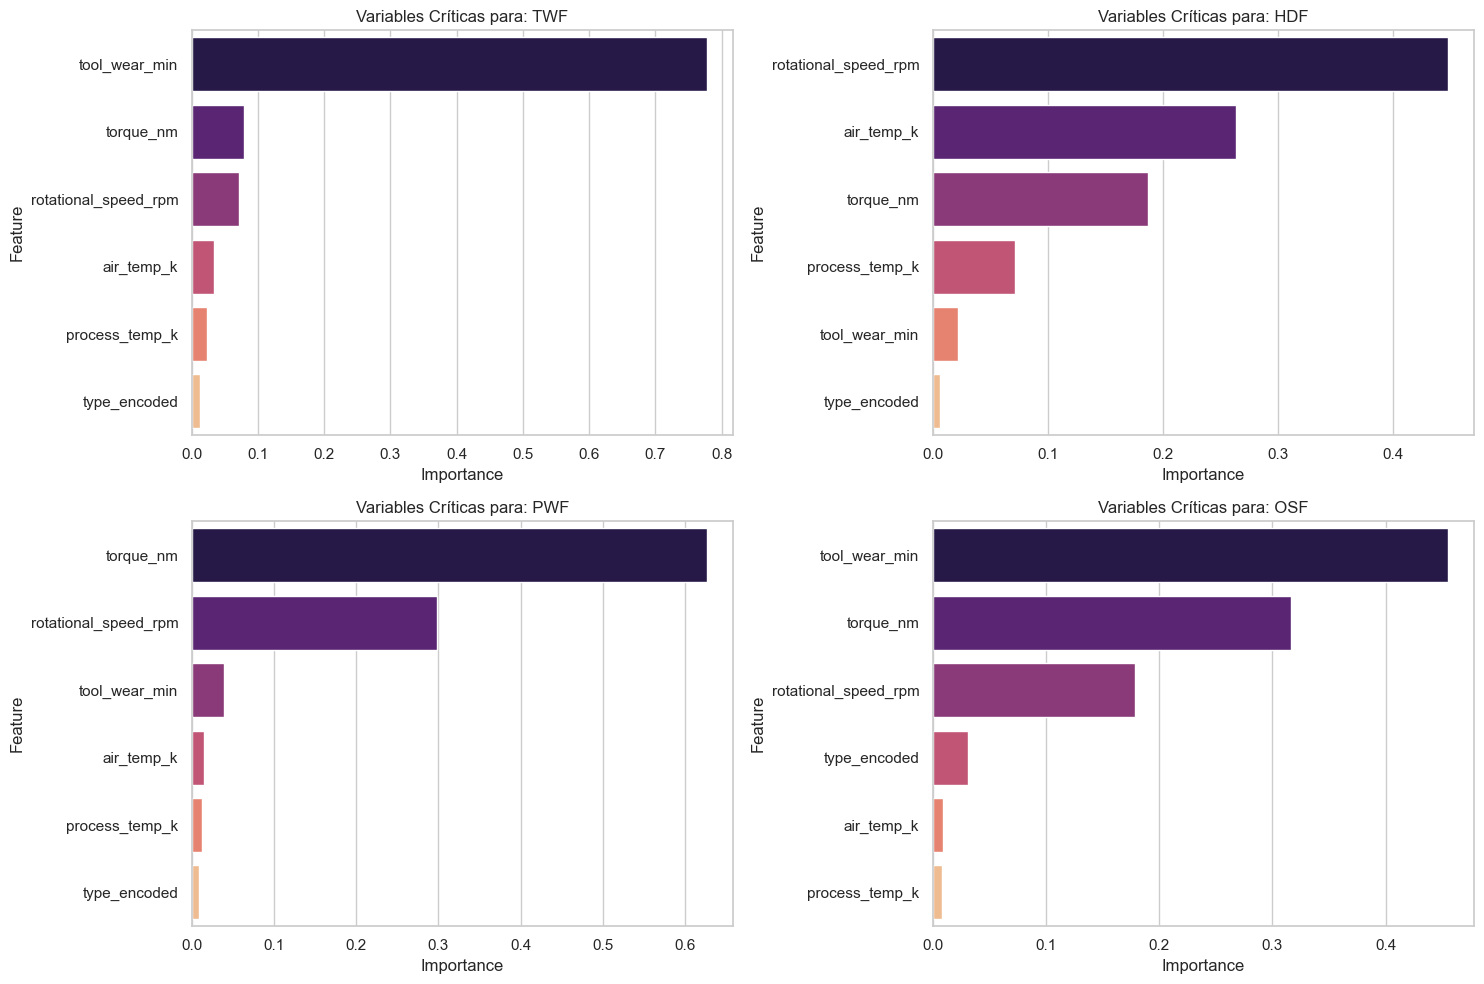

In [153]:
from src.visualization.plot_results import guardar_grafico
# target_cols es tu lista: ['TWF', 'HDF', 'PWF', 'OSF']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, falla in enumerate(target_cols):
    # Accedemos al modelo específico de esa falla
    importancia = rf_best.estimators_[i].feature_importances_

    df_temp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importancia
    }).sort_values(by='Importance', ascending=False)
    
    sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',   # <--- 1. Agrega esto (el color depende de la Feature)
    data=df_temp, 
    ax=axes[i], 
    palette='magma', 
    legend=False     # <--- 2. Agrega esto (oculta la leyenda redundante)
)
    axes[i].set_title(f'Variables Críticas para: {falla}')
    #guardar en reports/figures/
    guardar_grafico(fig, f'feat_import_{falla}', output_dir='reports/figures')

plt.tight_layout()
plt.show()


Analizando la importancia de las distintas variables para cada falla:

Para el tipo de falla de TWF-Tool Wear Failure (Por el uso de la herramienta o desgaste), como era de esperar el tiempo de uso en minutos es la mas determinante, pero para sorpresa, las que le siguen son las variables creadas wear_torque_product (producto entre el uso en minutos y el torque en Nm) y la variable Power (potencia). La temperatura afecta poco.

Para el tipo de falla HDF, sorprendentemente la variable mas determinante es la rotational_speed_rpm (velocidad de rotacion de la maquina) y luego la variable creada temp_delta (diferencia entre temperatura de aire y la del proceso) dando validez a su implementación.

Para la variable PWF no hay sopresas, la varible creada power es la principal y le siguen las de toque y velocidad de rotación.

Terminando con la variable OSF, dio resultado la implementacion de la variable wear_torque_product la mas determinante con diferencia.

### Conclusion del primer modelo

El random forest creado se eligio buscando el maximo rendimiento de la variable F1 (balance entre precisión y recall), pero dependiendo el contexto de la empresa la métrica podria ser otra, por ejemplo si el costo de falla es demasiado superior al de mantenimiento la metrica deberia ser recall. En este caso el random forest dio un f1= 0.65 siendo aceptable pero muy mejorable.

Opciones de mejora: El desbalance es gigantesco, podria mejorar mucho el rendimiento implementar un modelo XGBoost que actua mucho mejor frente a datos desbalanceados.

### Construir un modelo XGBoost


Su principal ventaja es el hiperparámetro scale_pos_weight, que permite asignar un peso mayor a la clase minoritaria directamente dentro de la función de pérdida. Esto obliga al modelo a "prestar más atención" a los eventos raros sin necesidad de utilizar técnicas de re-muestreo externas (como SMOTE o Undersampling) que podrían distorsionar la distribución real de los datos.

Además, al ser un algoritmo de gradient boosting, aprende de forma iterativa corrigiendo los errores previos, lo que suele funcionar muy bien para detectar patrones complejos en la clase minoritaria.

El parámetro scale_pos_weight es el contrapeso matemático que equilibra la balanza. Aquí tienes la implementación correcta. Dado que cada falla (TWF, HDF, etc.) tiene una cantidad diferente de casos positivos, no podemos usar un solo valor para todas. Debemos calcular el peso específico para cada una.

 La Matemática del Contrapeso: Para cada tipo de falla, el valor ideal de scale_pos_weight se calcula así:$$scale\_pos\_weight = \frac{\text{Cantidad de Casos Negativos (No Falla)}}{\text{Cantidad de Casos Positivos (Falla)}}$$Si tienes 9900 casos sanos y 100 fallas, el peso debe ser 99. Esto hace que el modelo trate 1 error de falla como si fueran 99 errores normales.

### Modelo XGBoost 1


#### Visualizamos los ratios de cada tipo de falla, necesarios para implementar la escala de peso en el modelo.

In [136]:
# Diccionario para guardar los modelos entrenados y resultados
modelos_xgb = {}
resultados_pred_1 = pd.DataFrame(index=X_test.index, columns=target_cols)
target_cols = ['tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure']
print("--- Iniciando Entrenamiento XGBoost con Pesos Dinámicos ---")

for falla in target_cols:
    # A. Calcular el peso específico para esta falla
    n_negativos = (y_train[falla] == 0).sum()
    n_positivos = (y_train[falla] == 1).sum()
    
    # Cálculo del scale_pos_weight recomendado
    ratio_balance = n_negativos / n_positivos
    
    print(f"\nEntrenando para: {falla}")
    print(f" - Ratio (Neg/Pos): {ratio_balance:.2f}")

--- Iniciando Entrenamiento XGBoost con Pesos Dinámicos ---

Entrenando para: tool_wear_failure
 - Ratio (Neg/Pos): 215.22

Entrenando para: heat_dissipation_failure
 - Ratio (Neg/Pos): 86.91

Entrenando para: power_failure
 - Ratio (Neg/Pos): 101.56

Entrenando para: overstrain_failure
 - Ratio (Neg/Pos): 102.90


#### Creamos el primer modelo XGBoost
Utilizando la metrica F1_score.

In [137]:
#Iniciar el XGBoost Clasificador con pesos dinámicos
from src.models.train_model import train_predict_xgb_dynamic_weights

# 1. Lista de tus fallas objetivo
target_cols = ['tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure']
modelos_xgb = {}
resultados_pred = pd.DataFrame(index=X_test.index, columns=target_cols)

modelos_xgb, resultados_pred = train_predict_xgb_dynamic_weights(
    X_train=X_train,
    y_train=y_train,
    target_cols=target_cols,
    X_test=X_test,
)


2026-01-08 20:15:24,541 - INFO - --- Iniciando Entrenamiento Iterativo XGBoost ---
2026-01-08 20:15:24,543 - INFO - Procesando objetivo: tool_wear_failure
2026-01-08 20:15:24,546 - INFO -  - Ratio (Neg/Pos) para tool_wear_failure: 215.22


Fitting 3 folds for each of 48 candidates, totalling 144 fits


2026-01-08 20:15:48,050 - INFO -  - Mejor F1 para tool_wear_failure: 0.1555
2026-01-08 20:15:48,058 - INFO - Procesando objetivo: heat_dissipation_failure
2026-01-08 20:15:48,060 - INFO -  - Ratio (Neg/Pos) para heat_dissipation_failure: 86.91


Fitting 3 folds for each of 48 candidates, totalling 144 fits


2026-01-08 20:16:13,982 - INFO -  - Mejor F1 para heat_dissipation_failure: 0.8046
2026-01-08 20:16:13,992 - INFO - Procesando objetivo: power_failure
2026-01-08 20:16:13,994 - INFO -  - Ratio (Neg/Pos) para power_failure: 101.56


Fitting 3 folds for each of 48 candidates, totalling 144 fits


2026-01-08 20:16:38,542 - INFO -  - Mejor F1 para power_failure: 0.8527
2026-01-08 20:16:38,557 - INFO - Procesando objetivo: overstrain_failure
2026-01-08 20:16:38,559 - INFO -  - Ratio (Neg/Pos) para overstrain_failure: 102.90


Fitting 3 folds for each of 48 candidates, totalling 144 fits


2026-01-08 20:17:03,347 - INFO -  - Mejor F1 para overstrain_failure: 0.8168
2026-01-08 20:17:03,358 - INFO - --- Entrenamiento Finalizado ---


📊 Gráfico guardado en: reports/figures\confusion_matrix_xgb1tool_wear_failure
📊 Gráfico guardado en: reports/figures\confusion_matrix_xgb1heat_dissipation_failure
📊 Gráfico guardado en: reports/figures\confusion_matrix_xgb1power_failure
📊 Gráfico guardado en: reports/figures\confusion_matrix_xgb1overstrain_failure


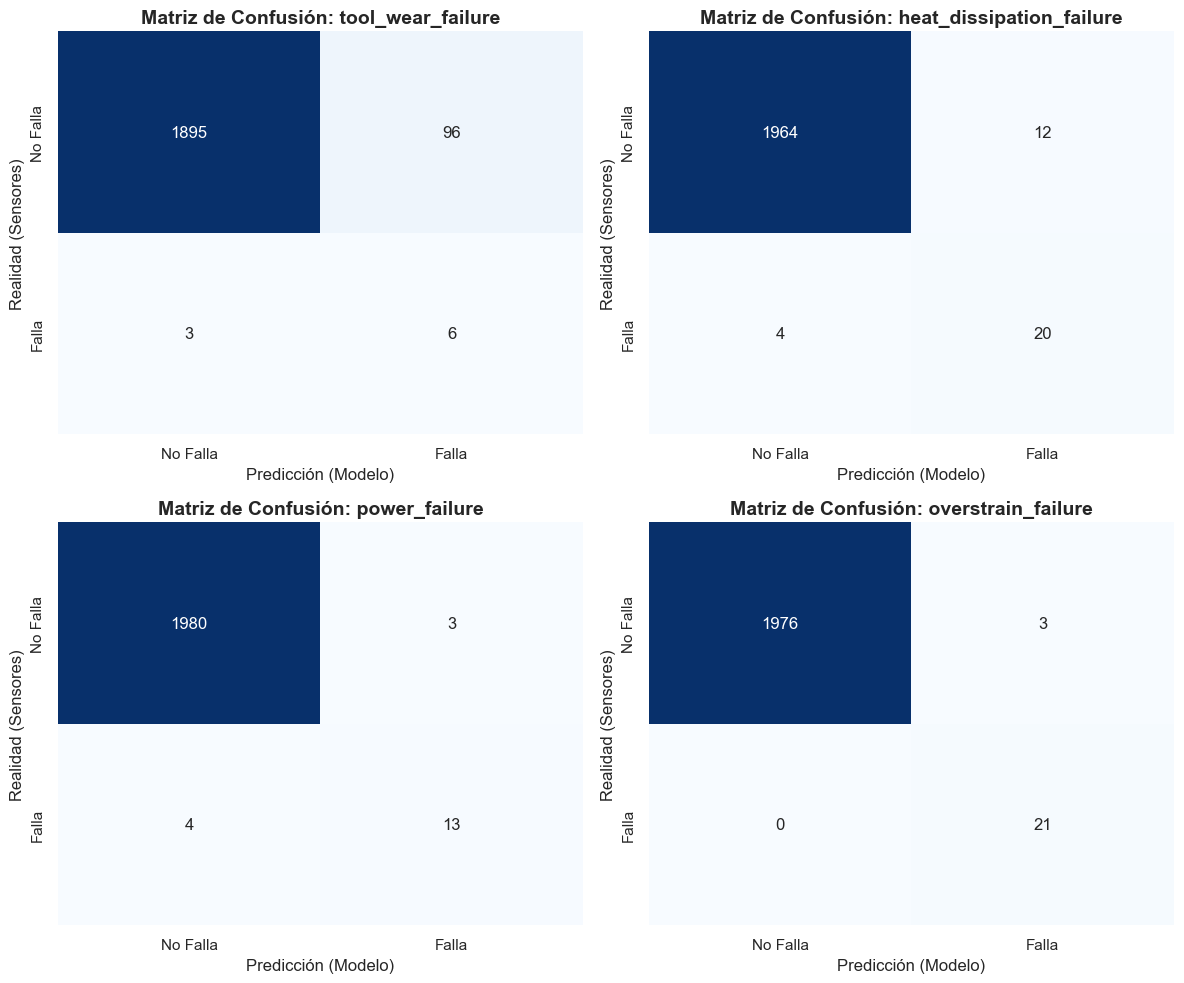

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 2. Configurar el tablero de gráficos (2x2)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, falla in enumerate(target_cols):
    # Obtener el modelo y hacer predicciones
    modelo = modelos_xgb[falla]
    y_pred = modelo.predict(X_test)
    
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test[falla], y_pred)
    
    # Graficar usando Seaborn
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    
    # Configuración de etiquetas
    axes[i].set_title(f'Matriz de Confusión: {falla}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicción (Modelo)')
    axes[i].set_ylabel('Realidad (Sensores)')
    axes[i].set_xticklabels(['No Falla', 'Falla'])
    axes[i].set_yticklabels(['No Falla', 'Falla'])
#guardar en reports/figures/
    guardar_grafico(fig, f'confusion_matrix_xgb1{falla}', output_dir='reports/figures')
plt.tight_layout()
plt.show()

Analisis: Vemos que el modelo no mejora significativamente con respecto al Random Forest, por lo tanto haremos un ajuste en la metrica utilizada.

### Modelo XGBoost 2
Creamos un nuevo modelo poniendo foco en mejorar la metrica "Area bajo la curva Precision-Recall" llamada AUCPR.

In [139]:
from src.models.optimize_aucpr import train_xgb_optimize_aucpr

# 1. Lista de tus fallas objetivo
target_cols = ['tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure']

# Diccionario para guardar los mejores modelos encontrados
best_models = {}
best_models = train_xgb_optimize_aucpr(X_train,
    y_train,
    target_cols
)

2026-01-08 20:17:20,758 - INFO - --- Iniciando Optimización XGBoost basada en AUCPR ---
2026-01-08 20:17:20,760 - INFO - Analizando falla: tool_wear_failure
2026-01-08 20:17:20,762 - INFO -  - Ratio calculado (Neg/Pos): 215.22


Fitting 3 folds for each of 24 candidates, totalling 72 fits


2026-01-08 20:17:49,952 - INFO - ✅ Mejor AUCPR para tool_wear_failure: 0.1041
2026-01-08 20:17:49,954 - INFO -    Mejores params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(322.8243243243243)}
2026-01-08 20:17:49,956 - INFO - Analizando falla: heat_dissipation_failure
2026-01-08 20:17:49,958 - INFO -  - Ratio calculado (Neg/Pos): 86.91


Fitting 3 folds for each of 24 candidates, totalling 72 fits


2026-01-08 20:18:01,994 - INFO - ✅ Mejor AUCPR para heat_dissipation_failure: 0.8593
2026-01-08 20:18:01,996 - INFO -    Mejores params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': np.float64(130.36813186813185)}
2026-01-08 20:18:01,997 - INFO - Analizando falla: power_failure
2026-01-08 20:18:02,000 - INFO -  - Ratio calculado (Neg/Pos): 101.56


Fitting 3 folds for each of 24 candidates, totalling 72 fits


2026-01-08 20:18:10,993 - INFO - ✅ Mejor AUCPR para power_failure: 0.8856
2026-01-08 20:18:10,994 - INFO -    Mejores params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': np.float64(152.34615384615387)}
2026-01-08 20:18:10,996 - INFO - Analizando falla: overstrain_failure
2026-01-08 20:18:10,998 - INFO -  - Ratio calculado (Neg/Pos): 102.90


Fitting 3 folds for each of 24 candidates, totalling 72 fits


2026-01-08 20:18:17,984 - INFO - ✅ Mejor AUCPR para overstrain_failure: 0.9199
2026-01-08 20:18:17,986 - INFO -    Mejores params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'scale_pos_weight': np.float64(102.8961038961039)}
2026-01-08 20:18:17,987 - INFO - --- Optimización Finalizada ---


Analizando el parametro AUCPR, puede sorprender el valor para el tipo de falla tool_wear_failure, pero este depende de que tan grande es el desbalance del tipo de falla, el valor 0,1041 sigue siendo varias veces mas grande que el valor para un modelo que predice al azar (para la misma falla) debido a que es la falla con mayor desbalance.

In [140]:
resultados_pred_1 = pd.DataFrame(index=X_test.index, columns=target_cols)
for falla in target_cols: 
   resultados_pred_1[falla] = best_models[falla].predict(X_test)


📊 Gráfico guardado en: reports/figures\confusion_matrix_xgb2_tool_wear_failure
📊 Gráfico guardado en: reports/figures\confusion_matrix_xgb2_heat_dissipation_failure
📊 Gráfico guardado en: reports/figures\confusion_matrix_xgb2_power_failure
📊 Gráfico guardado en: reports/figures\confusion_matrix_xgb2_overstrain_failure


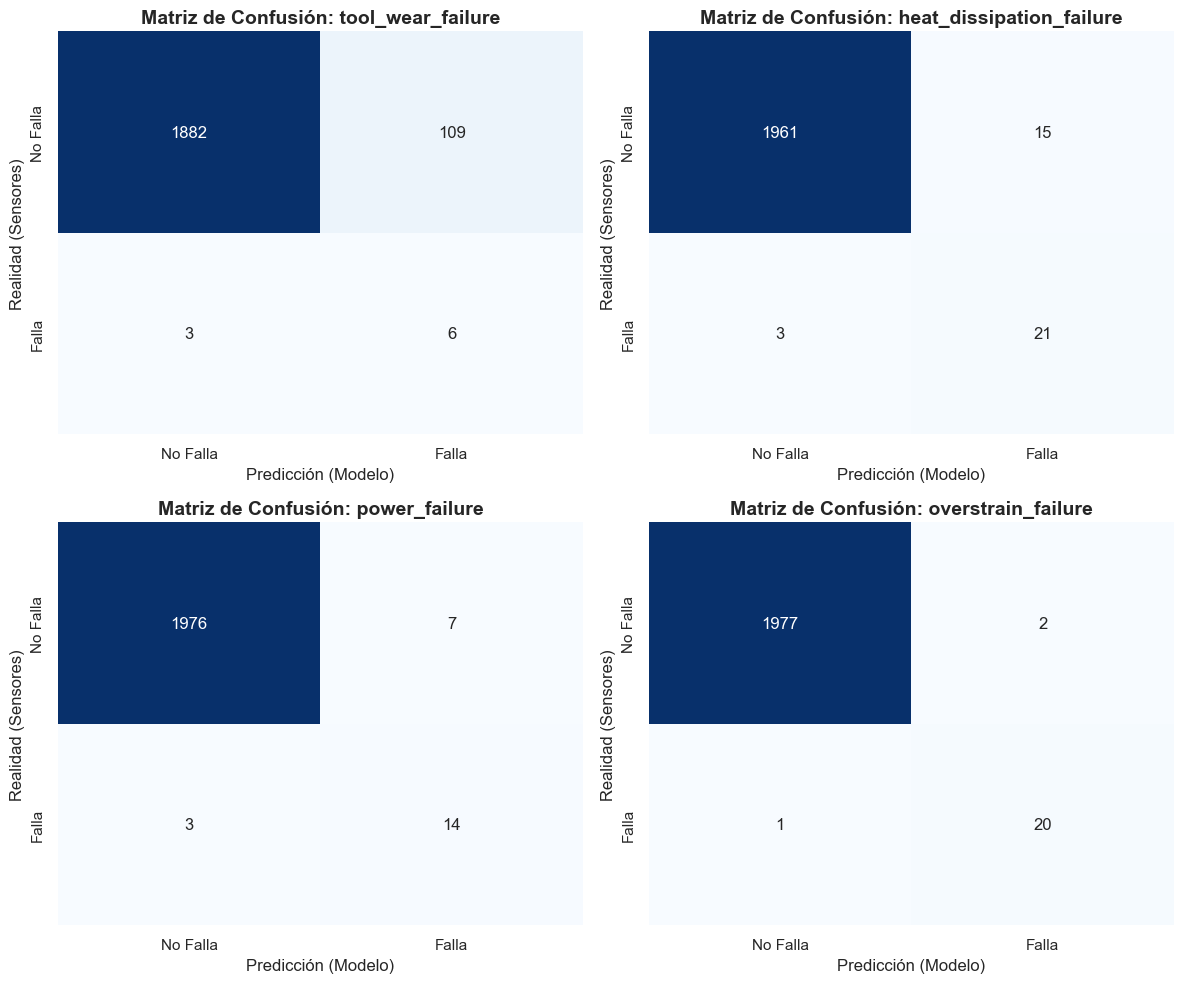

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from src.visualization.plot_results import guardar_grafico
# 2. Configurar el tablero de gráficos (2x2)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, falla in enumerate(target_cols):
    # Obtener el modelo y hacer predicciones
    modelo = best_models[falla]
    y_pred = modelo.predict(X_test)
    
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test[falla], y_pred)
    
    # Graficar usando Seaborn
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    
    # Configuración de etiquetas
    axes[i].set_title(f'Matriz de Confusión: {falla}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicción (Modelo)')
    axes[i].set_ylabel('Realidad (Sensores)')
    axes[i].set_xticklabels(['No Falla', 'Falla'])
    axes[i].set_yticklabels(['No Falla', 'Falla'])
#guardar en reports/figures
    guardar_grafico(fig, f'confusion_matrix_xgb2_{falla}', output_dir='reports/figures')
plt.tight_layout()
plt.show()

Analisis: se puede apreciar que el rendimiento mejoro para encontrar las fallas en el falla tool_wear (por el uso de la herramienta o desgaste) pero con una mayor cantidad de falsos positivos (109 vs 15 del random forest) pudiendose observar que este tipo de falla es muy aleatoria y dificil de predecir, se debera tomar una decision si quedarse con el XGBoost o el Random Forest, y para la falla por sobre carga (overstrain_failure) se pudo predecir cada una de las fallas.

📊 Gráfico guardado en: reports/figures\feat_import_xgb2_tool_wear_failure
📊 Gráfico guardado en: reports/figures\feat_import_xgb2_heat_dissipation_failure
📊 Gráfico guardado en: reports/figures\feat_import_xgb2_power_failure
📊 Gráfico guardado en: reports/figures\feat_import_xgb2_overstrain_failure


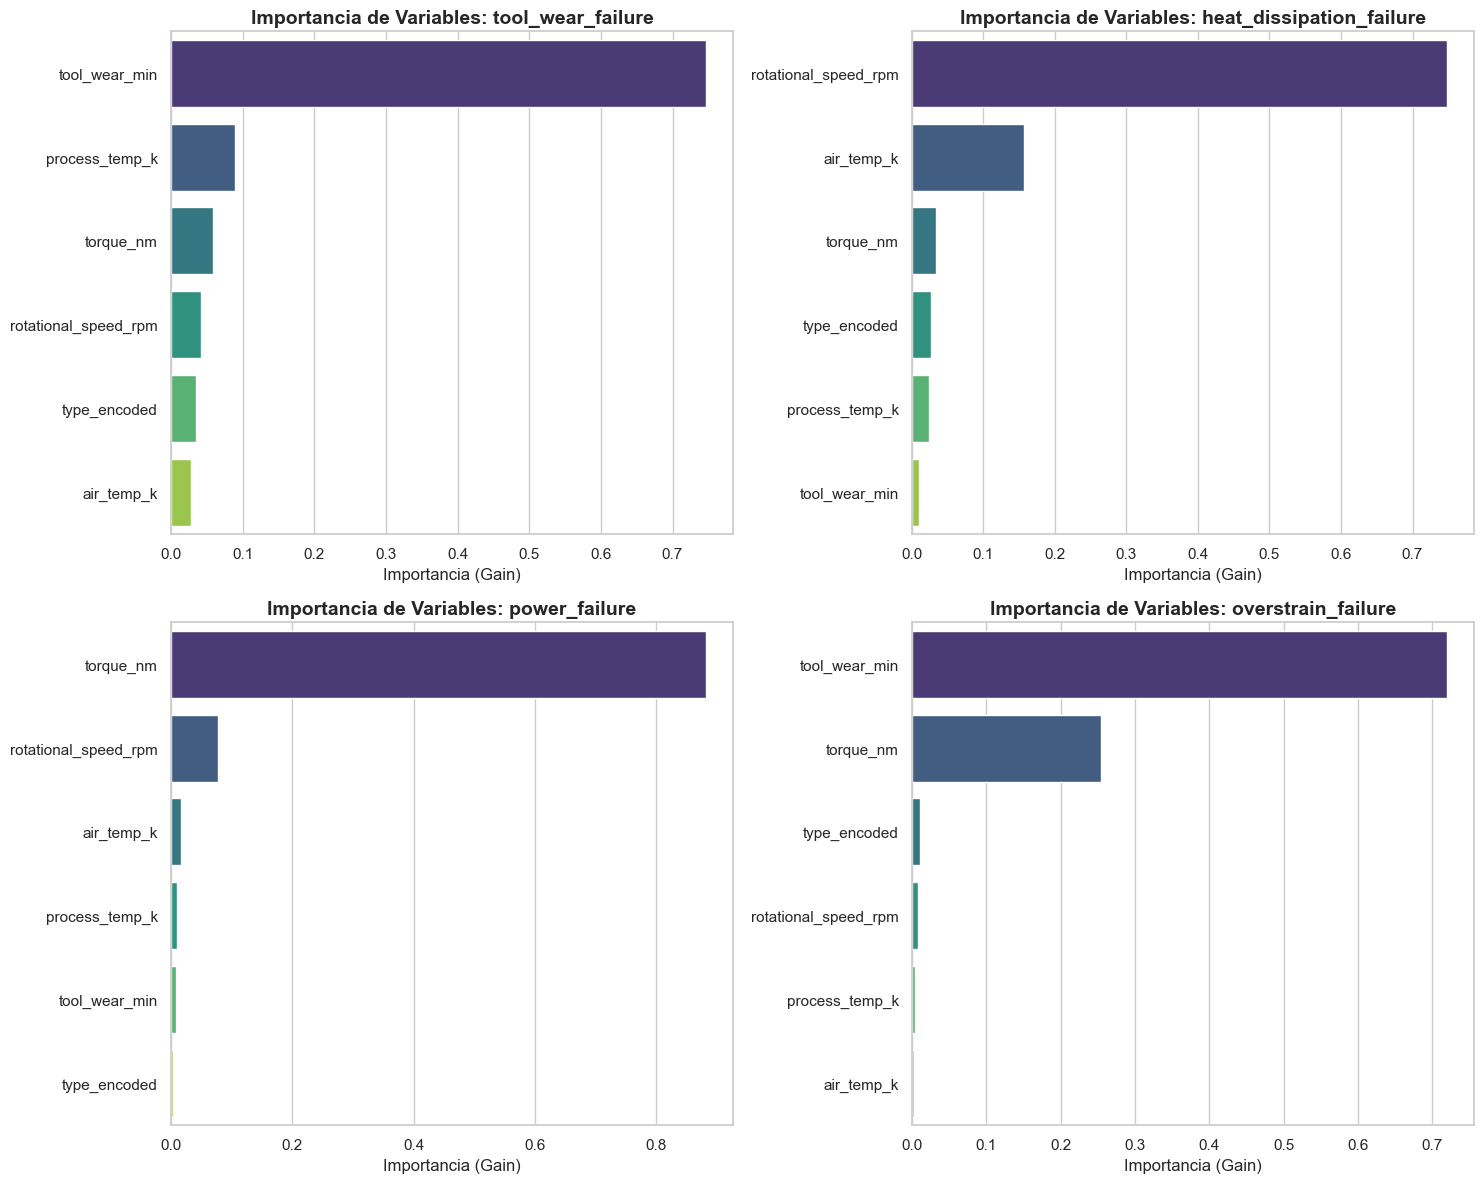

In [142]:

# Obtener los nombres de las columnas
features = X.columns

# Configurar el lienzo
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for i, falla in enumerate(target_cols):
    # 1. Obtener el modelo específico
    modelo = best_models[falla]
    
    # 2. Extraer importancias (usando Ganancia por defecto)
    importancias = modelo.feature_importances_
    
    # 3. Crear un DataFrame temporal
    df_imp = pd.DataFrame({
        'Feature': features,
        'Importance': importancias
    }).sort_values(by='Importance', ascending=False)
    
    # 4. Graficar
    sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',   # <--- 1. Agrega esto (el color depende de la Feature)
    data=df_imp, 
    ax=axes[i], 
    palette='viridis', 
    legend=False     # <--- 2. Agrega esto (oculta la leyenda redundante)
)
    axes[i].set_title(f'Importancia de Variables: {falla}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Importancia (Gain)')
    axes[i].set_ylabel('')
    #guardar en reports/figures
    guardar_grafico(fig, f'feat_import_xgb2_{falla}', output_dir='reports/figures')
plt.tight_layout()
plt.show()

Generando: Feature Importance...
📊 Gráfico guardado en: reports/figures\feat_import_global_xgb


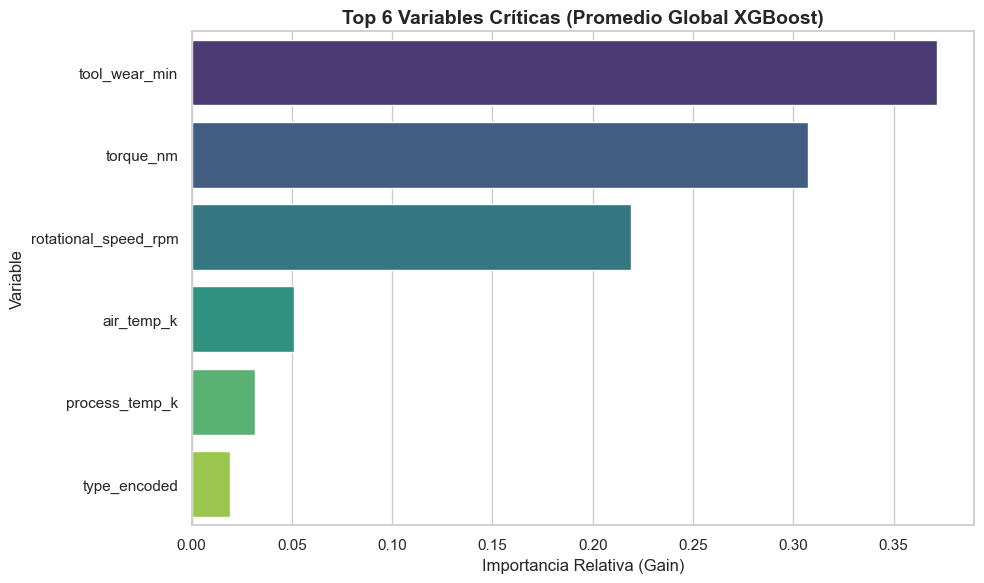

In [143]:
#Importancia de caracteristicas globales combinadas de los modelos XGBoost optimizados por AUC-PR
# 1. Configuración de Directorios
output_dir = 'reports/figures'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directorio creado: {output_dir}")

# Configuración estética general
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})
# --- GRÁFICO 1: FEATURE IMPORTANCE (Resumen Global) ---
print("Generando: Feature Importance...")

features = X_test.columns
importancias_globales = pd.DataFrame(index=features)

for falla in target_cols:
    if falla in best_models:
        importancias_globales[falla] = best_models[falla].feature_importances_

# Promedio para el gráfico resumen
importancias_globales['Media'] = importancias_globales.mean(axis=1)
df_plot = importancias_globales.sort_values(by='Media', ascending=False).head(6) # Top 10

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Media', 
    y=df_plot.index, 
    hue=df_plot.index,  # <--- 1. Asigna el índice (nombres de features) al color
    data=df_plot, 
    palette='viridis', 
    legend=False        # <--- 2. Oculta la leyenda para que no estorbe
)
plt.title('Top 6 Variables Críticas (Promedio Global XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia Relativa (Gain)')
plt.ylabel('Variable')
# guardar en reports/figures
guardar_grafico(plt, 'feat_import_global_xgb', output_dir=output_dir)
plt.show()


Saber la importancia de cada variable nos pued guiar para formular estrategias para el dia a dia de la empresa. A partir del gafico podriamos comunicar al area de mantenimiento que las variables que mas atencion merecen es el tiempo de uso acumulado de la herramienta, el torque y la velocidad de rotacion de la maquina.

# Etapa: Ejecutar 
- Interpretacion de los modelos y estrategia recomendada.
- Aplicacion a un escenario economico


### Conclusion

En este proyecto se desarrollaron y compararon dos arquitecturas de Machine Learning: Random Forest y XGBoost. El primero destacó por su transparencia, permitiendo validar mediante 'feature importance' las leyes físicas que rigen cada fallo. Por otro lado, XGBoost demostró una mayor capacidad predictiva al gestionar el desbalance de clases mediante pesos dinámicos (scale_pos_weight), aunque con una estructura lógica más compleja.

La evaluación no se limitó al Accuracy, sino que se centró en el equilibrio entre Precisión y Recall. Para una gestión de planta que priorice la continuidad operativa, se recomienda configurar los modelos para maximizar el Recall, asumiendo un incremento controlado en inspecciones preventivas (Falsos Positivos) a cambio de eliminar las paradas de línea no programadas (Falsos Negativos).

Estrategia Final Sugerida: Se propone un enfoque híbrido de mantenimiento. Para el desgaste de herramienta (TWF), dadas sus características de degradación lineal, se recomienda un esquema de Mantenimiento Preventivo basado en horas de uso, en especifico realizar mantenimiento cuando el tiempo de uso supere los 200 minutos. Para las fallas térmicas y de potencia (HDF y PWF), se recomienda un esquema de Mantenimiento Predictivo (CBM) utilizando el modelo XGBoost, optimizando así la vida útil de los componentes sin comprometer la confiabilidad del sistema.

### Aplicacion a un Escenario Economico

#### Definición del Escenario Económico
Definimos una matriz de costos para palantear un escenario real de ejeplo para definir que tanto conviene aplicar una estrategia de mantenimiento predictivo puro, en el que trataremos de predecir las cada falla con el modelo generado XGBoost.

#### 💰 Matriz de Costos y Definiciones Financieras

Para alinear el modelo con los objetivos del negocio, se definieron los siguientes costos operativos. Esta matriz penaliza severamente los **Falsos Negativos**, priorizando la detección de fallas sobre la pureza estadística.

| Escenario | Definición Técnica | Costo (USD) | Justificación del Negocio |
| :--- | :--- | :---: | :--- |
| **True Positive (TP)** | Predicción Correcta | **$500** | Costo del Mantenimiento Preventivo (Repuesto + Mano de obra planificada). |
| **False Positive (FP)** | Falsa Alarma | **$150** | Costo de inspección (Tiempo del técnico revisando una máquina sana). |
| **False Negative (FN)** | Falla No Detectada | **$10,000** | **Crítico:** Reparación correctiva + Parada de línea + Lucro cesante. |
| **True Negative (TN)** | Operación Normal | **$0** | Máquina produciendo ingresos. No hay gasto de mantenimiento. |

#### Analisis Financiero

In [144]:
from src.models.evaluate.financial_analysis import calculate_financial_metrics, print_executive_report

COSTOS = {
    'mantenimiento_preventivo': 500,   # TP: Detectamos la falla y reparamos a tiempo
    'inspeccion_innecesaria': 150,     # FP: Inspeccionamos y no había nada (Costo Hh)
    'falla_no_planificada': 10000,     # FN: Se rompió la máquina (Parada + Repuestos)
    'operacion_normal': 0              # TN: Todo sigue bien
}

df_reporte, accumulators = calculate_financial_metrics(
    models_dict=best_models,
    X_test=X_test,
    y_test=y_test,
    costs=COSTOS
)
print_executive_report(df_reporte, accumulators)


2026-01-08 20:18:55,900 - INFO - --- Iniciando cálculo de métricas financieras ---


--- ANÁLISIS FINANCIERO POR TIPO DE FALLA ---

Desglose por Falla:


,Falla,"Costo ""Dejar Romper""",Costo con IA,Ahorro Generado,Fallas Detectadas (TP),Fallas Perdidas (FN),Falsas Alarmas (FP)
0,tool_wear_failure,"$90,000.00","$49,350.00","$40,650.00",6,3,109
1,heat_dissipation_failure,"$240,000.00","$42,750.00","$197,250.00",21,3,15
2,power_failure,"$170,000.00","$38,050.00","$131,950.00",14,3,7
3,overstrain_failure,"$210,000.00","$20,300.00","$189,700.00",20,1,2



RESUMEN EJECUTIVO GLOBAL (Toda la Planta)
Costo Política Actual (Run-to-Failure):  $710,000.00
Costo Operativo con Modelos IA:          $150,450.00
------------------------------------------------------
AHORRO TOTAL PROYECTADO:                 $559,550.00
RETORNO DE INVERSIÓN (ROI):              371.9%


Analisis:

Antes de variar y buscar los umbrales de decision optimos podemos ver que la estrategia planteado es muy conveniente para este caso, con un retorno de inverison del 371%, con ahorro de 560 mil dolares.

#### Optimización de Umbrales de Decisión:
 Iteración sobre el espacio de probabilidad (0.0 a 1.0) para identificar el punto de corte que minimiza la función de costo total, transformando las probabilidades continuas del XGBoost en decisiones binarias accionables.

2026-01-08 20:18:56,917 - INFO - Calculando umbrales óptimos para: tool_wear_failure
2026-01-08 20:18:56,984 - INFO - Calculando umbrales óptimos para: heat_dissipation_failure
2026-01-08 20:18:57,076 - INFO - Calculando umbrales óptimos para: power_failure
2026-01-08 20:18:57,143 - INFO - Calculando umbrales óptimos para: overstrain_failure



--- RESULTADOS DE OPTIMIZACIÓN DE UMBRALES ---
Falla tool_wear_failure: Umbral Óptimo = 0.20 | Costo Mínimo = $37,850.00
Falla heat_dissipation_failure: Umbral Óptimo = 0.05 | Costo Mínimo = $19,200.00
Falla power_failure: Umbral Óptimo = 0.10 | Costo Mínimo = $20,100.00
Falla overstrain_failure: Umbral Óptimo = 0.30 | Costo Mínimo = $11,100.00

📊 Gráfico guardado en: reports/figures\cost_threshold_curve


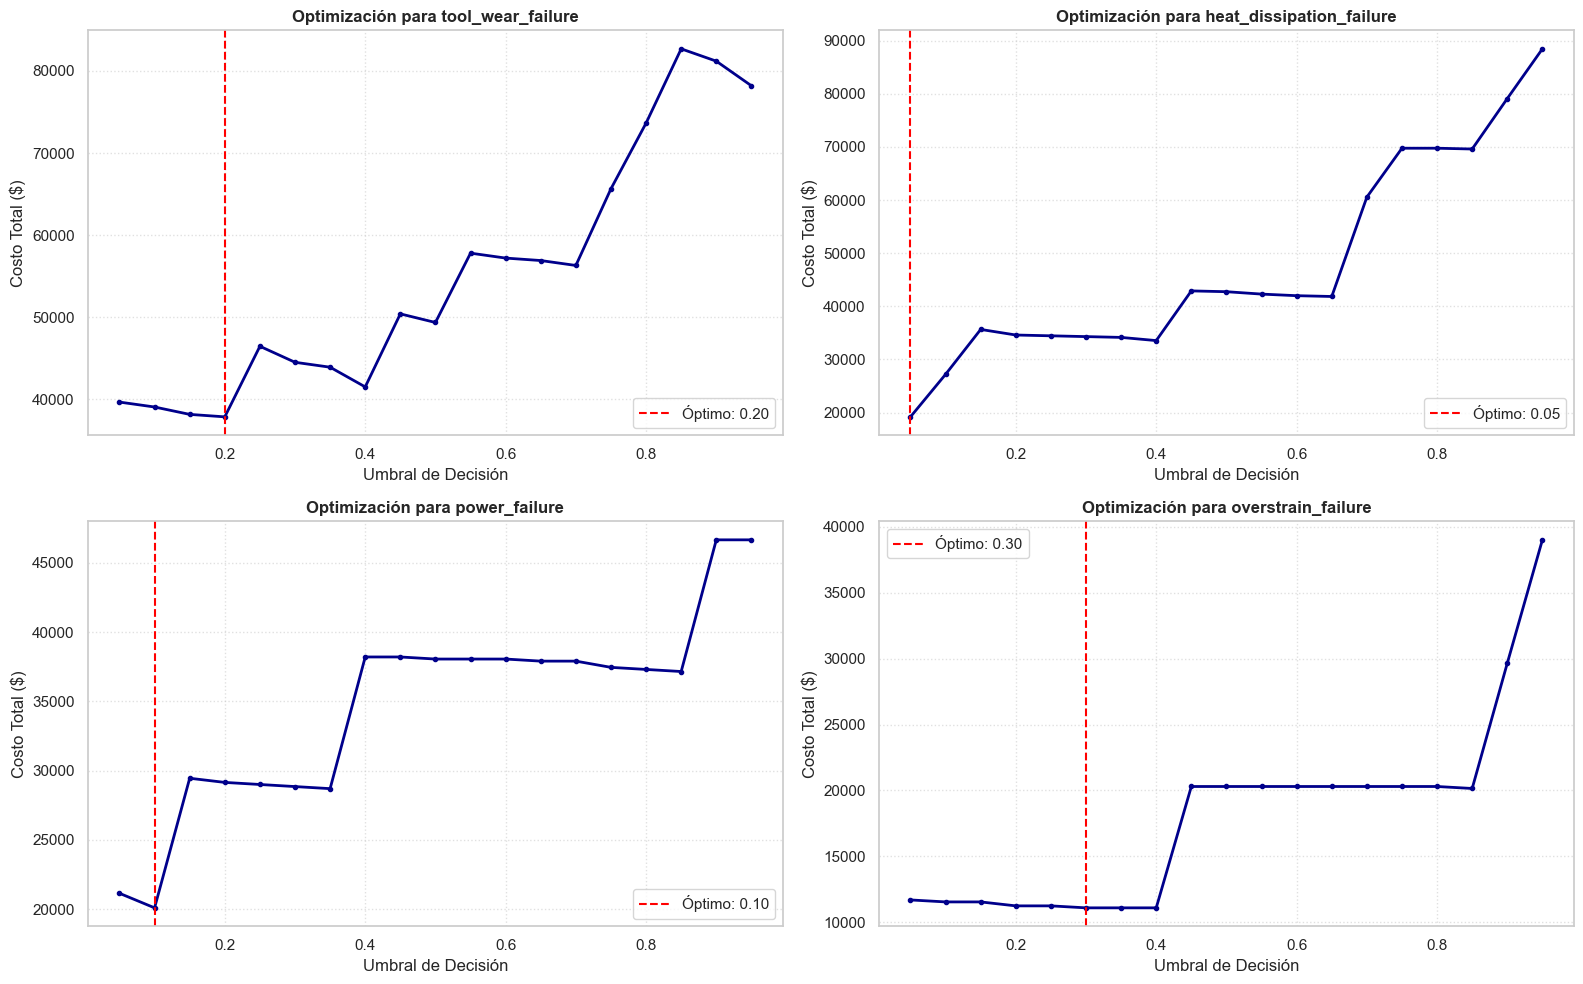

{'tool_wear_failure': np.float64(0.2),
 'heat_dissipation_failure': np.float64(0.05),
 'power_failure': np.float64(0.1),
 'overstrain_failure': np.float64(0.3)}

In [145]:
from src.models.evaluate.threshold_optimization import calculate_optimal_thresholds,plot_threshold_optimization

COSTOS = {
    'preventivo': 500,        # TP
    'inspeccion': 150,        # FP
    'falla_critica': 10000,   # FN
    'normal': 0               # TN
}

resultados, umbrales_optimos = calculate_optimal_thresholds(
    models_dict=best_models,
    X_test=X_test,
    y_test=y_test,
    costs=COSTOS
)
plot_threshold_optimization(resultados,filename ='cost_threshold_curve',output_dir='reports/figures')


### Evaluación de Estrategia Híbrida vs. Predictiva Pura: 
Con el objetivo de minimizar aún más los costos operativos, capitalizamos la fuerte correlación lineal observada entre la falla por desgaste (TWF) y el tiempo de uso. En este paso, contrastamos el rendimiento financiero de una Estrategia Híbrida (Mantenimiento Preventivo determinista al superar los 200 min para TWF + XGBoost para fallas complejas) frente a una estrategia puramente basada en IA. El objetivo es validar si un enfoque simple y robusto supera al modelado complejo para fallas de degradación lineal.

--- COMPARATIVA DE ESTRATEGIAS PARA tool_wear_failure ---
1. Estrategia Regla (>200 min): $26,850.00
   - Fallas evitadas: 9
   - Roturas no previstas: 0
   - Cambios prematuros: 149

2. Estrategia IA (Umbral 0.20): $37,850.00
   - Fallas evitadas: 8
   - Roturas no previstas: 1
   - Cambios prematuros: 159

------------------------------------------------
DIFERENCIA A FAVOR DE LA IA: $-11,000.00


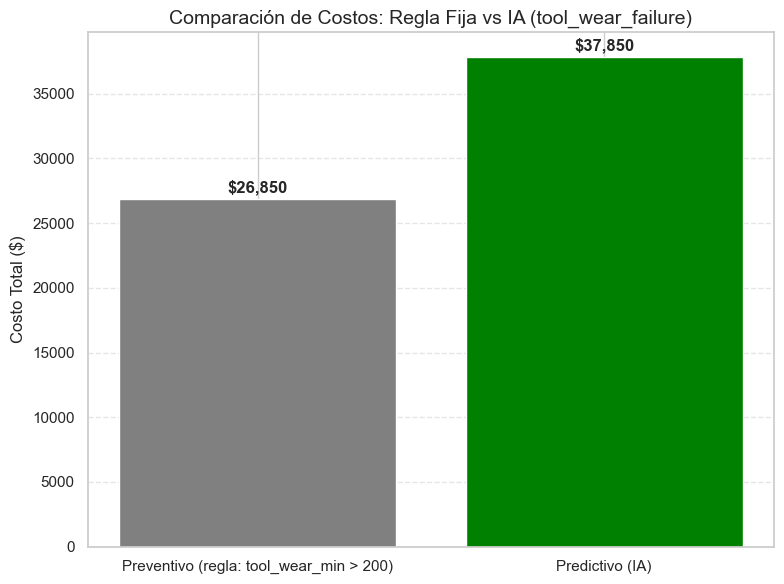

In [146]:
from src.models.evaluate.comparison import compare_rule_vs_ai
# Ejecutar la comparación y generación de gráficos
compare_rule_vs_ai(
    model=best_models['tool_wear_failure'],
    X_test=X_test,
    y_test=y_test,
    umbral_ai=umbrales_optimos['tool_wear_failure'],
    columna_regla='tool_wear_min',
    valor_regla=200,
    falla_target='tool_wear_failure',
    costs=COSTOS,
    output_dir='reports/figures'
)

Para este dataset específico, la falla por desgaste (TWF) tiene una correlación lineal extremadamente fuerte con el tiempo de uso. En este caso específico, implementar un modelo complejo de IA no justifica el retorno de inversión frente a una política preventiva estricta. Sin embargo, la IA sigue siendo superior en las otras fallas estocásticas (PWF, HDF, OSF) donde no existe una regla lineal simple.

### Analisis financieron global con Estrategia Híbrida

In [147]:
from src.models.evaluate.hybrid_strategy import calculate_hybrid_metrics, print_hybrid_report

# 1. Configuración de Costos y Columnas
COSTOS = {
    'preventivo': 500,       # TP
    'inspeccion': 150,       # FP
    'falla': 10000,          # FN
    'normal': 0              # TN
}
configuracion_reglas = {
    'tool_wear_failure': {
        'col': 'tool_wear_min', 
        'threshold': 200
    }
}
df_hibrido, metrics = calculate_hybrid_metrics(
    models_dict=best_models,
    thresholds_dict=umbrales_optimos,
    X_test=X_test,
    y_test=y_test,
    costs=COSTOS,
    rule_exceptions=configuracion_reglas
)

print_hybrid_report(df_hibrido, metrics)
metrics

2026-01-08 20:19:11,401 - INFO - --- Iniciando cálculo de Estrategia Híbrida ---


--- REPORTE FINANCIERO: ESTRATEGIA HÍBRIDA (REGLA + IA) ---


,Tipo de Falla,Estrategia Usada,"Costo ""Dejar Romper""",Costo Estrategia,Ahorro Neto,Fallas Evitadas (TP),Fallas No Detectadas (FN),Inspecciones Extra (FP)
0,tool_wear_failure,Regla Fija (>200 tool_wear_min),"$90,000","$26,850","$63,150",9,0,149
1,heat_dissipation_failure,XGBoost (Umbral 0.05),"$240,000","$19,200","$220,800",24,0,48
2,power_failure,XGBoost (Umbral 0.10),"$170,000","$20,100","$149,900",16,1,14
3,overstrain_failure,XGBoost (Umbral 0.30),"$210,000","$11,100","$198,900",21,0,4



RESUMEN EJECUTIVO DE PLANTA (Estrategia Mixta)
Costo Actual (Reactivo/RTF):         $710,000.00
Costo Propuesto (Híbrido):           $77,250.00
----------------------------------------------------------
AHORRO TOTAL ANUAL ESTIMADO:         $632,750.00
RETORNO DE INVERSIÓN (ROI):          819.1%
REDUCCIÓN DE PARADAS NO PLANIFICADAS: 89.1%


{'costo_rtf_total': np.float64(710000.0),
 'costo_estrategia_total': np.float64(77250.0),
 'ahorro_total': np.float64(632750.0),
 'roi': np.float64(819.093851132686),
 'reduccion_paradas': np.float64(89.11971830985915)}

Gráfico guardado en: reports/figures/comparacion_estrategias.png


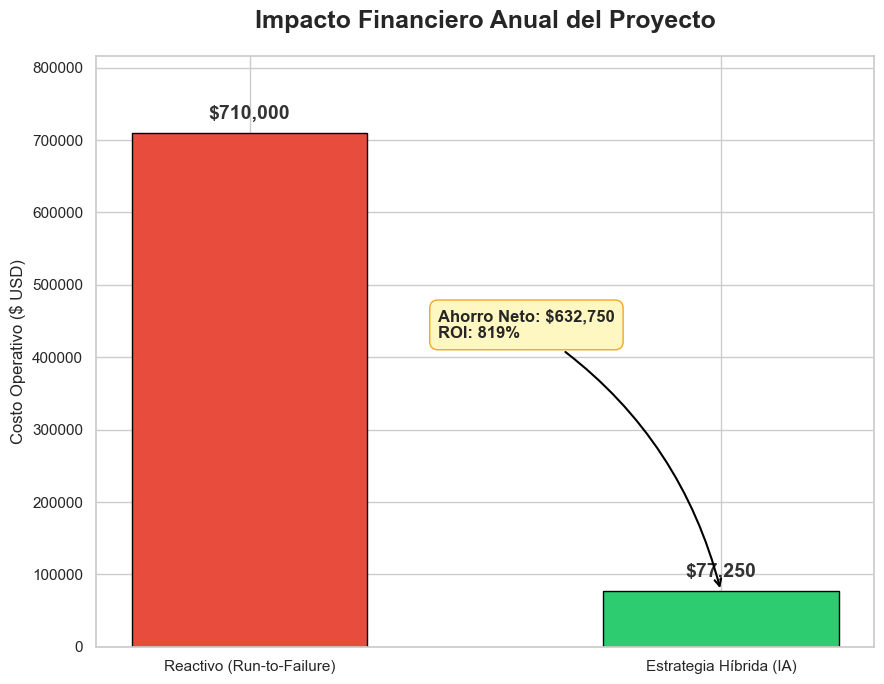

In [148]:
from src.visualization.plot_comparison_final import plot_comparacion_final

costo_rtf_total, costo_estrategia_total = metrics['costo_rtf_total'], metrics['costo_estrategia_total']
fig = plot_comparacion_final(costo_rtf_total, costo_estrategia_total, guardar_como='reports/figures/comparacion_estrategias.png')


Análisis de Viabilidad y Recomendación

Los datos son concluyentes: mantener la política actual de "operar hasta la falla" es insostenible, con un costo oculto de $710,000 anuales. La estrategia propuesta reduce este pasivo en un 89%.

Es importante destacar que el costo propuesto ($77,250) corresponde a intervenciones preventivas controladas y planificadas, lo cual permite al departamento de mantenimiento recuperar el control de su agenda. Al evitar casi el 90% de las roturas imprevistas, el equipo deja de "apagar fuegos" para concentrarse en tareas de mejora continua. Se recomienda la adopción inmediata del modelo híbrido escalonado.

# Guardar los Mejores Modelos

In [155]:
#Guardar los mejores modelos para utilizarlos luego
import joblib

# 1. Asegúrate de tener tu diccionario listo.
# Imaginemos que se ve así (usa tus nombres reales de variables):
diccionario_modelos = {
    'Falla_Desgaste (TWF)': best_models['tool_wear_failure'],
    'Falla_Calor (HDF)': best_models['heat_dissipation_failure'],
    'Falla_Potencia (PWF)': best_models['power_failure'],
    'Falla_Sobrecarga (OSF)': best_models['overstrain_failure']
}

# 2. Guardar el diccionario completo en un archivo
# Esto crea una "cápsula" con todos tus modelos dentro
joblib.dump(diccionario_modelos, 'best_models_xgb_mantenimiento.pkl')

print("¡Modelos guardados exitosamente en 'best_models_xgb_mantenimiento.pkl'!")

¡Modelos guardados exitosamente en 'best_models_xgb_mantenimiento.pkl'!
